# Full fMRI lag-selection: six emotions and PCA

This notebook consolidates the full analysis of the six emotion dimensions and the three PCA components in one file. Core pipeline:

**Raw predictor → permutation → smoothing → lag (−12 s to +12 s) → single-lag whole-brain test → best-lag reselection in every permutation → selection-replay → Holm correction → voxel-wise BH-FDR → cortical surface maps.**

Only two arrow-free PNGs are produced in the end: the six-emotion figure and the PCA figure. Region arrows and Top5 tables are not written by this notebook.

## Run and reproduction notes

- TR = 2 s; candidate lags are −6 to +6 TR, i.e. −12 s to +12 s, 13 lags in total.
- Each dimension uses 2,000 circular-shift permutations; every permutation restarts from the raw predictor and re-runs smoothing, lag construction, and the full lag selection.
- The saved outputs come from a completed production run, so the results are visible on opening the notebook.
- Rerunning from scratch recomputes all permutations (long runtime) and updates the CSV, NPZ, NIfTI, and PNG files in the corresponding results directories.
- The six emotions and the PCA components use independent random seeds; per-dimension seeds, window lengths, batch sizes, and memory settings are grouped in their respective parameter cells.

### Directory layout

- `data/`: BOLD cache, emotion/PCA time series, gray-matter mask, and source metadata.
- `results/`: statistics, NIfTI maps, and the two arrow-free PNGs generated by a from-scratch run.
- The notebook uses relative paths; start Jupyter from the directory containing this file.
- The full 2,000 permutations are computationally heavy; a CUDA GPU is recommended.


# Part 1: full raw-first lag-selection for the six emotions

This part keeps the fully executed pipeline for the six emotion dimensions: input checks, BH validation, observed-data lag scan, raw-first permutation, voxel-wise max-over-lag correction, selection-replay, Holm correction, null-distribution diagnostics, and NIfTI export.

In [8]:
import os
# compute and store os.environ['KMP_DUPLICATE_LIB_OK'] as input for the following statements
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import json
import platform
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

%matplotlib inline

# compute device actually used by PyTorch; CUDA if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Python:", platform.python_version())
print("torch:", torch.__version__)
print("device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))



Python: 3.12.12
torch: 2.5.1+cu124
device: cuda
GPU: NVIDIA GeForce RTX 4080


In [19]:
# search upward from the working directory for the project root, avoiding hard-coded machine paths.
def find_project_root(start: Path) -> Path:
    for candidate in [start.resolve(), *start.resolve().parents]:
        marker = candidate / "data" / "cache_signals_nowhiten_smooth_fwhm6_unit.npy"
        if marker.exists():
            return candidate
    raise FileNotFoundError("Package directory not found; run from the notebook directory or a subdirectory.")

# project root; all later data paths are built relative to it
ROOT = find_project_root(Path.cwd())
ANALYSIS = ROOT / "data"
OUTPUT_DIR = ROOT / "results" / "six_emotion"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# path to the non-prewhitened, FWHM=6 mm, unit-norm BOLD voxel time-series cache
Y_CACHE = ANALYSIS / "cache_signals_nowhiten_smooth_fwhm6_unit.npy"
PREDS_PATH = ANALYSIS / "preds_smoothed_danmu.npy"
SOURCE_META = ANALYSIS / "provenance" / "emotion_source_meta.json"
SOURCE_CSV = ANALYSIS / "provenance" / "emotion_source_summary.csv"

# the six emotion dimensions and their fixed processing order
EMOTIONS = ["Happiness", "Surprise", "Fear", "Sadness", "Anger", "Disgust"]
WINDOWS = [1,1,1,1,1,1]
TR = 2.0
LAGS = list(range(-6, 7))
ALPHA = 0.05
MIN_DIST = 800
N_PERM = 2000
BATCH = 128
MAXT_BATCH = 24
SEED_BASE = 42
PERM_SEEDS = [SEED_BASE + (dim + 1) * 100_000 + 10_000 for dim in range(6)]

# configuration dictionary parsed from the original pipeline JSON
source_meta = json.loads(SOURCE_META.read_text(encoding="utf-8"))
source_results = pd.read_csv(SOURCE_CSV)
source_by_emotion = source_results.set_index("emotion")

# summary of the key data paths, lags, windows, permutation count, and seeds of this notebook
config = {
    "project_root": str(ROOT),
    "y_cache": str(Y_CACHE.relative_to(ROOT)),
    "predictors": str(PREDS_PATH.relative_to(ROOT)),
    "source_result_csv": str(SOURCE_CSV.relative_to(ROOT)),
    "lags_TR": LAGS,
    "lags_seconds": [lag * TR for lag in LAGS],
    "windows_TR": dict(zip(EMOTIONS, WINDOWS)),
    "n_permutations": N_PERM,
    "permutation_pipeline": "raw->permute->smooth->lag->analysis",
    "predictor_input_boundary": (
        "raw-first is relative to the notebook moving-average/lag pipeline; "
        "the loaded file is preds_smoothed_danmu.npy and upstream HRF/design construction is unchanged"
    ),
    "window_selection": "fixed per emotion; only lag is reselected inside each permutation",
    "strict_shift_min_distance_TR": MIN_DIST,
    "alpha": ALPHA,
    "seed_base": SEED_BASE,
}
display(pd.Series(config, name="value").to_frame())
print("original results meta:", source_meta)



,value
project_root,\\10.16.57.94\dataset1\xinke\Danmu\fmri_lag_se...
y_cache,data\cache_signals_nowhiten_smooth_fwhm6_unit.npy
predictors,data\preds_smoothed_danmu.npy
source_result_csv,data\provenance\emotion_source_summary.csv
lags_TR,"[-6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6]"
lags_seconds,"[-12.0, -10.0, -8.0, -6.0, -4.0, -2.0, 0.0, 2...."
windows_TR,"{'Happiness': 1, 'Surprise': 1, 'Fear': 1, 'Sa..."
n_permutations,2000
permutation_pipeline,raw->permute->smooth->lag->analysis
predictor_input_boundary,raw-first is relative to the notebook moving-a...


original results meta: {'candidates': 'analysis\\results_surfacepeak_shortlag_selectedwindow_shiftstrict800_2026-05-25\\danmu_surfacepeak_candidates.csv', 'preds': 'osfstorage-archive\\preds_smoothed_danmu.npy', 'y_unit_cache': 'analysis\\cache_signals_nowhiten_smooth_fwhm6_unit.npy', 'methods': ['shift_strict800'], 'n_perm': 2000, 'min_shift': 30, 'iaaft_iter': 50, 'seed': 42, 'batch_size': 128, 'tr': 2.0, 'alpha': 0.05, 'save_voxel_arrays': 'analysis\\results_surfacepeak_shortlag_selectedwindow_shiftstrict800_2026-05-25\\danmu\\voxel_arrays', 'prewhitening': 'none', 'fdr': 'BH-FDR over all gray-matter voxels', 'n_timepoints': 3595, 'n_voxels': 43783, 'emotion_order': ['Happiness', 'Surprise', 'Fear', 'Sadness', 'Anger', 'Disgust']}


In [20]:

t0 = time.time()
# unit-norm BOLD time-points × voxels matrix loaded from disk
y_unit = np.load(Y_CACHE).astype(np.float32, copy=False)
preds = np.load(PREDS_PATH).astype(np.float32)
print(preds.shape)
T, V = y_unit.shape
preds = preds[:T]

# BOLD matrix copied to the compute device, reused by all matrix multiplications
y_unit_gpu = torch.tensor(y_unit, dtype=torch.float32, device=device)
del y_unit

print(f"BOLD cache: T={T}, V={V}")
print(f"predictors: {preds.shape}")
print(f"load time: {time.time() - t0:.2f}s")



(3599, 6)
BOLD cache: T=3595, V=43783
predictors: (3595, 6)
load time: 7.30s


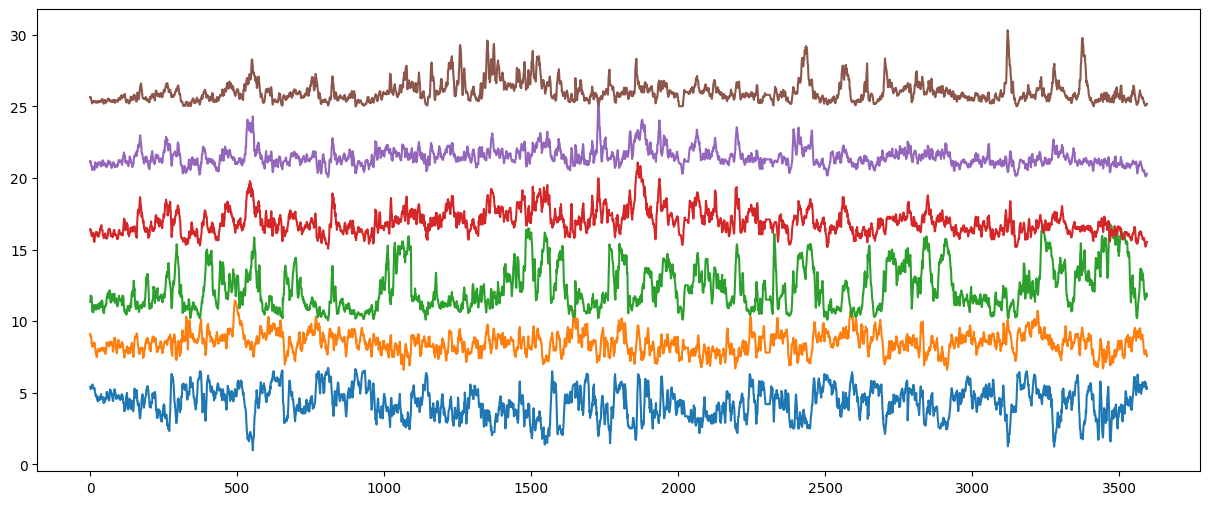

In [18]:
plt.figure(figsize=(15,6))
for i in range(6):
    plt.plot(preds[:,i]+5*i)
plt.show()

In [21]:
# moving_average(x, win): centered moving average of a 1-D predictor series.
def moving_average(x, win):
    if win <= 1:
        return x.astype(np.float32, copy=True)
    kernel = np.ones(win, dtype=np.float32) / float(win)
    return np.convolve(x.astype(np.float32), kernel, mode="same").astype(np.float32)

# apply_lag(x, lag): shift a time series by an integer number of TRs with edge handling.
def apply_lag(x, lag):
    if lag == 0:
        return x.astype(np.float32, copy=True)
    y = np.roll(x, lag).astype(np.float32)
    if lag > 0:
        y[:lag] = y[lag]
    else:
        y[lag:] = y[lag - 1]
    return y

# zscore_1d(x): de-mean and standard-deviation normalize a 1-D series.
def zscore_1d(x):
    x = x.astype(np.float32, copy=False)
    x = x - np.float32(x.mean())
    sd = np.float32(x.std())
    if sd > np.float32(1e-10):
        x = x / sd
    return x.astype(np.float32, copy=False)

# build_column(raw, lag, window, out_len): build the design-matrix column for one emotion at one lag.
def build_column(raw, lag, window, out_len):
    x = moving_average(raw.astype(np.float32, copy=True), window)
    x = apply_lag(x, lag)
    return zscore_1d(x[:out_len])

# prepare_unit_x(x, target_device): convert a predictor into a unit-norm tensor for correlation encoding.
def prepare_unit_x(x, target_device=device):
    xc = x.astype(np.float32, copy=False) - np.float32(x.mean())
    norm = float(np.sqrt(np.dot(xc, xc)))
    if norm <= 1e-12:
        raise ValueError("Zero-norm predictor")
    return torch.tensor(xc / norm, dtype=torch.float32, device=target_device)

# benjamini_hochberg(p_values): BH-FDR correction of a set of voxel p values.
def benjamini_hochberg(p_values):
    p = np.asarray(p_values, dtype=np.float64)
    order = np.argsort(p)
    ranked = p[order]
    q_ranked = ranked * p.size / np.arange(1, p.size + 1)
    q_ranked = np.minimum.accumulate(q_ranked[::-1])[::-1]
    q = np.empty_like(q_ranked)
    q[order] = q_ranked
    return np.clip(q, 0.0, 1.0)

# strict_shift_indices(n_t, n_perm, min_distance, seed): generate strict circular-shift permutation offsets.
def strict_shift_indices(n_t, n_perm, min_distance, seed):
    rng = np.random.default_rng(seed)
    return rng.integers(min_distance, n_t - min_distance + 1, size=n_perm, dtype=np.int64)

# holm_adjust(p_values): Holm family-wise correction of the six emotion-level p values.
def holm_adjust(p_values):
    p = np.asarray(p_values, dtype=float)
    order = np.argsort(p)
    adjusted_sorted = np.maximum.accumulate((p.size - np.arange(p.size)) * p[order])
    adjusted = np.empty_like(adjusted_sorted)
    adjusted[order] = np.minimum(adjusted_sorted, 1.0)
    return adjusted

# bh_rejection_count_from_sorted_p(sorted_p, alpha): batch-compute the BH rejection count of each permutation.
def bh_rejection_count_from_sorted_p(sorted_p, alpha=ALPHA):
    m = sorted_p.shape[1]
    ranks = torch.arange(1, m + 1, device=sorted_p.device, dtype=torch.int64)
    thresholds = alpha * ranks.to(torch.float32) / float(m)
    passed = sorted_p <= thresholds.unsqueeze(0)
    return torch.where(passed, ranks.unsqueeze(0), 0).max(dim=1).values

# re-center an already z-scored 1-D predictor and scale it to unit L2 norm.
def prepare_unit_np(x):
    x = x.astype(np.float32, copy=False)
    xc = x - np.float32(x.mean())
    norm = float(np.sqrt(np.dot(xc, xc)))
    if norm <= 1e-12:
        raise ValueError("Zero-norm permuted predictor")
    return (xc / norm).astype(np.float32, copy=False)

# for a batch of permutations, strictly apply raw → permutation → smoothing → lag → z-score → unit norm.
def build_raw_first_permuted_batch(raw, shifts, lags, window, out_len, target_device=device):
    batch_array = np.empty((len(shifts), len(lags), out_len), dtype=np.float32)
    for perm_index, shift in enumerate(shifts):
        raw_permuted = np.roll(raw, int(shift)).astype(np.float32, copy=False)
        smoothed_permuted = moving_average(raw_permuted, window)
        for lag_index, lag in enumerate(lags):
            lagged_permuted = apply_lag(smoothed_permuted, lag)
            standardized = zscore_1d(lagged_permuted[:out_len])
            batch_array[perm_index, lag_index] = prepare_unit_np(standardized)
    return torch.from_numpy(batch_array).to(target_device)



In [22]:
toy = torch.tensor(
    [
        [0.020, 0.024, 0.900, 0.950],  # rank 1 fails but rank 2 passes; BH step-up should reject 2
        [0.001, 0.010, 0.040, 0.900],
    ],
    dtype=torch.float32,
    device=device,
)
toy_sorted, _ = torch.sort(toy, dim=1)
torch_counts = bh_rejection_count_from_sorted_p(toy_sorted).cpu().numpy()
numpy_counts = np.array([(benjamini_hochberg(row) < ALPHA).sum() for row in toy.cpu().numpy()])
print("torch BH counts:", torch_counts.tolist())
print("numpy BH counts:", numpy_counts.tolist())
# assert np.array_equal(torch_counts, numpy_counts); stop immediately on shape or count mismatch so wrong results are never written
assert np.array_equal(torch_counts, numpy_counts)
print("BH step-up test: PASS")

# use a small simulated series to verify that, under the current edge handling, "shift after preprocessing" and "preprocess after raw shift" are not equivalent.
toy_raw = np.linspace(-1.0, 1.0, 64, dtype=np.float32) + 0.2 * np.sin(np.arange(64, dtype=np.float32))
toy_shift, toy_window, toy_lag = 11, 5, 3
toy_processed_first = torch.roll(
    prepare_unit_x(
        build_column(toy_raw, toy_lag, toy_window, len(toy_raw)),
        target_device=torch.device("cpu"),
    ),
    toy_shift,
).numpy()
toy_raw_first = build_raw_first_permuted_batch(
    toy_raw,
    np.asarray([toy_shift]),
    [toy_lag],
    toy_window,
    len(toy_raw),
    target_device=torch.device("cpu"),
)[0, 0].numpy()
toy_order_max_abs_diff = float(np.max(np.abs(toy_processed_first - toy_raw_first)))
assert toy_order_max_abs_diff > 1e-6
print(f"order check done: max abs difference between processed-first and raw-first = {toy_order_max_abs_diff:.6g}")



torch BH counts: [2, 2]
numpy BH counts: [2, 2]
BH step-up test: PASS
order check done: max abs difference between processed-first and raw-first = 0.323293


In [23]:
# ============================================================
# Voxel-wise max-over-lag permutation inference
#
# Statistic:
#
#   T_v = max_lag R2(v, lag)
#
# Null:
#
#   T_null_v = max_lag R2_perm(v, lag)
#
# Then:
#   voxel-wise empirical p
#   BH-FDR correction
#
# ============================================================


voxelwise_results = {}
summary_rows = []


for dim, emotion in enumerate(EMOTIONS):

    t0 = time.time()

    print(
        f"\nRunning voxel-wise lag correction: {emotion}"
    )


    # --------------------------------------------------------
    # 1. Observed data
    # --------------------------------------------------------

    raw_predictor = preds[:, dim].astype(
        np.float32,
        copy=False
    )


    # Same permutation shifts as original pipeline
    shifts = strict_shift_indices(
        T,
        N_PERM,
        MIN_DIST,
        PERM_SEEDS[dim]
    )


    # Build all lag regressors:
    #
    # raw predictor
    # -> smoothing
    # -> lag
    # -> z/unit norm

    observed_x_lags = torch.stack(
        [
            prepare_unit_x(
                build_column(
                    raw_predictor,
                    lag,
                    WINDOWS[dim],
                    T
                )
            )

            for lag in LAGS
        ],
        dim=0
    )


    with torch.no_grad():

        observed_r2_lags = (
            observed_x_lags @ y_unit_gpu
        ).square()


    # shape:
    # n_lags × n_voxels

    r2_lags_array = (
        observed_r2_lags
        .cpu()
        .numpy()
        .astype(np.float32)
    )


    # --------------------------------------------------------
    # 2. Voxel-wise optimal lag
    # --------------------------------------------------------

    optimal_lag_index = np.argmax(
        r2_lags_array,
        axis=0
    )


    optimal_lag_TR = np.asarray(
        LAGS
    )[optimal_lag_index]


    optimal_lag_seconds = (
        optimal_lag_TR * TR
    )


    max_r2 = np.max(
        r2_lags_array,
        axis=0
    )


    print(
        f"{emotion}: "
        f"max R2={max_r2.max():.5f}, "
        f"mean optimal lag="
        f"{optimal_lag_seconds.mean():.2f}s"
    )



    del observed_x_lags, observed_r2_lags

    if device.type == "cuda":
        torch.cuda.empty_cache()



    # --------------------------------------------------------
    # 3. Permutation null distribution
    #
    # For each permutation:
    #
    # raw shift
    # -> smoothing
    # -> all lags
    # -> R2
    # -> max over lag
    #
    # Store voxel-wise null max R2
    # --------------------------------------------------------


    counts = torch.ones(
        V,
        dtype=torch.int32,
        device=device
    )


    # optional:
    # save full null distribution if memory allows
    #
    # null_max_r2 = np.zeros(
    #     (N_PERM, V),
    #     dtype=np.float32
    # )


    for start in range(
        0,
        N_PERM,
        MAXT_BATCH
    ):

        batch_shifts = shifts[
            start:start+MAXT_BATCH
        ]


        permuted_x_lags = (
            build_raw_first_permuted_batch(
                raw_predictor,
                batch_shifts,
                LAGS,
                WINDOWS[dim],
                T,
            )
        )


        with torch.no_grad():

            permuted_r2 = (
                permuted_x_lags.reshape(
                    -1,
                    T
                )
                @ y_unit_gpu
            ).square()


            permuted_r2 = (
                permuted_r2
                .reshape(
                    len(batch_shifts),
                    len(LAGS),
                    V
                )
            )


            # max over lag for every permutation and voxel

            perm_max_r2 = (
                permuted_r2
                .max(dim=1)
                .values
            )


            counts += (
                perm_max_r2
                >= torch.tensor(
                    max_r2,
                    dtype=torch.float32,
                    device=device
                ).unsqueeze(0)
            ).sum(dim=0).to(torch.int32)



        del (
            permuted_x_lags,
            permuted_r2,
            perm_max_r2
        )


        if device.type == "cuda":
            torch.cuda.empty_cache()



    # --------------------------------------------------------
    # 4. Voxel-wise permutation p
    # --------------------------------------------------------

    p_lag_corrected = (
        counts
        .cpu()
        .numpy()
        .astype(np.float32)
        /
        float(N_PERM + 1)
    )


    q_lag_corrected = (
        benjamini_hochberg(
            p_lag_corrected
        )
        .astype(np.float32)
    )


    sig_mask = (
        q_lag_corrected < ALPHA
    )


    n_sig = int(
        sig_mask.sum()
    )


    # --------------------------------------------------------
    # 5. Save results
    # --------------------------------------------------------

    voxelwise_results[emotion] = {

        "max_r2":
            max_r2,

        "optimal_lag_TR":
            optimal_lag_TR,

        "optimal_lag_seconds":
            optimal_lag_seconds,

        "p_lag_corrected":
            p_lag_corrected,

        "q_lag_corrected":
            q_lag_corrected,

        "sig_mask":
            sig_mask,

        "r2_lags":
            r2_lags_array,

        "permutation_order":
            "raw->permute->smooth->lag->max-over-lag",
    }



    # --------------------------------------------------------
    # 6. Summary
    # --------------------------------------------------------

    sig_lags = optimal_lag_seconds[
        sig_mask
    ]


    if len(sig_lags) > 0:

        values, counts_lag = np.unique(
            sig_lags,
            return_counts=True
        )

        modal_lag = (
            values[
                np.argmax(counts_lag)
            ]
        )

    else:

        modal_lag = np.nan



    summary_rows.append(
        {

            "emotion":
                emotion,

            "n_significant_voxels":
                n_sig,

            "max_R2":
                float(
                    max_r2.max()
                ),

            "mean_optimal_lag_seconds":
                float(
                    np.mean(
                        optimal_lag_seconds
                    )
                ),

            "median_optimal_lag_seconds":
                float(
                    np.median(
                        optimal_lag_seconds
                    )
                ),

            "modal_optimal_lag_seconds":
                float(
                    modal_lag
                ),

            "permutation_order":
                "raw->permute->smooth->lag->max-over-lag"

        }
    )


    print(
        f"{emotion:<10}"
        f" q<.05 voxels={n_sig:6d}, "
        f"modal lag={modal_lag:+.0f}s, "
        f"time={time.time()-t0:.1f}s"
    )



summary_df = pd.DataFrame(
    summary_rows
)


summary_df.to_csv(
    OUTPUT_DIR /
    "fmri_voxelwise_optimal_lag_summary.csv",
    index=False,
    encoding="utf-8-sig"
)


print("\nDone")
display(summary_df)


Running voxel-wise lag correction: Happiness
Happiness: max R2=0.03746, mean optimal lag=-0.42s
Happiness  q<.05 voxels=  1212, modal lag=-4s, time=1.8s

Running voxel-wise lag correction: Surprise
Surprise: max R2=0.03191, mean optimal lag=-1.09s
Surprise   q<.05 voxels=  2669, modal lag=-4s, time=1.5s

Running voxel-wise lag correction: Fear
Fear: max R2=0.03596, mean optimal lag=-0.82s
Fear       q<.05 voxels=  4844, modal lag=-4s, time=1.5s

Running voxel-wise lag correction: Sadness
Sadness: max R2=0.02519, mean optimal lag=1.18s
Sadness    q<.05 voxels=   530, modal lag=+12s, time=1.5s

Running voxel-wise lag correction: Anger
Anger: max R2=0.02748, mean optimal lag=0.48s
Anger      q<.05 voxels=   923, modal lag=+12s, time=1.5s

Running voxel-wise lag correction: Disgust
Disgust: max R2=0.02954, mean optimal lag=-0.51s
Disgust    q<.05 voxels=   594, modal lag=-12s, time=1.5s

Done


,emotion,n_significant_voxels,max_R2,mean_optimal_lag_seconds,median_optimal_lag_seconds,modal_optimal_lag_seconds,permutation_order
0,Happiness,1212,0.037457,-0.419524,-2.0,-4.0,raw->permute->smooth->lag->max-over-lag
1,Surprise,2669,0.031913,-1.085627,-2.0,-4.0,raw->permute->smooth->lag->max-over-lag
2,Fear,4844,0.035956,-0.823653,-2.0,-4.0,raw->permute->smooth->lag->max-over-lag
3,Sadness,530,0.025191,1.179956,2.0,12.0,raw->permute->smooth->lag->max-over-lag
4,Anger,923,0.027484,0.479775,0.0,12.0,raw->permute->smooth->lag->max-over-lag
5,Disgust,594,0.029542,-0.510472,-2.0,-12.0,raw->permute->smooth->lag->max-over-lag


In [ ]:
import nibabel as nib
from nilearn.maskers import NiftiMasker

# ============================================================
# Save voxel-wise max-R2 maps, p/q maps and optimal lag maps
# ============================================================

NIFTI_DIR = ANALYSIS / 'new_nifti_results'
MASK_PATH = ANALYSIS / "epi_gm_mask.nii.gz"
FIG_DIR = ANALYSIS / 'figures'

mask_img = nib.load(
    str(MASK_PATH)
)

mask_bool = (
    mask_img.get_fdata() > 0
)


masker = NiftiMasker(
    mask_img=mask_img,
    standardize=False,
    dtype="float32"
).fit()



corrected_maps = {}
array_bundle = {}
map_rows = []


for emotion in EMOTIONS:


    # --------------------------------------------------------
    # Results from voxel-wise optimal lag inference
    # --------------------------------------------------------

    rec = voxelwise_results[emotion]


    # Each voxel:
    #
    # max over lag R2
    max_r2 = rec["max_r2"].astype(
        np.float32,
        copy=False
    )


    # voxel-specific optimal lag
    optimal_lag_TR = rec[
        "optimal_lag_TR"
    ].astype(
        np.float32,
        copy=False
    )


    optimal_lag_seconds = rec[
        "optimal_lag_seconds"
    ].astype(
        np.float32,
        copy=False
    )


    # permutation + FDR
    p_corr = rec[
        "p_lag_corrected"
    ].astype(
        np.float32,
        copy=False
    )


    q_corr = rec[
        "q_lag_corrected"
    ].astype(
        np.float32,
        copy=False
    )


    sig_mask = (
        q_corr < ALPHA
    )


    # --------------------------------------------------------
    # Only display significant voxels
    # --------------------------------------------------------

    sig_r2 = np.where(
        sig_mask,
        max_r2,
        0.0
    ).astype(
        np.float32
    )


    sig_lag = np.where(
        sig_mask,
        optimal_lag_seconds,
        np.nan
    ).astype(np.float32)

    expected = int(
        rec["sig_mask"].sum()
    )


    assert int(sig_mask.sum()) == expected


    assert (
        max_r2.shape
        ==
        p_corr.shape
        ==
        q_corr.shape
        ==
        optimal_lag_seconds.shape
        ==
        (V,)
    )



    # --------------------------------------------------------
    # Convert to NIfTI
    # --------------------------------------------------------

    max_r2_img = masker.inverse_transform(
        max_r2
    )


    sig_r2_img = masker.inverse_transform(
        sig_r2
    )


    p_img_raw = masker.inverse_transform(
        p_corr
    )


    q_img_raw = masker.inverse_transform(
        q_corr
    )


    optimal_lag_img = masker.inverse_transform(
        optimal_lag_seconds
    )


    # sig_lag_img = masker.inverse_transform(
    #     sig_lag
    # )
    
    sig_lag_vol = np.full(
        mask_bool.shape,
        np.nan,
        dtype=np.float32
    )

    sig_lag_vol[mask_bool] = sig_lag


    sig_lag_img = nib.Nifti1Image(
        sig_lag_vol,
        mask_img.affine,
        # mask_img.header
    )



    # remove outside-mask values

    p_data = p_img_raw.get_fdata(
        dtype=np.float32
    )

    q_data = q_img_raw.get_fdata(
        dtype=np.float32
    )


    p_data[~mask_bool] = np.nan
    q_data[~mask_bool] = np.nan


    p_img = nib.Nifti1Image(
        p_data,
        p_img_raw.affine,
        p_img_raw.header
    )


    q_img = nib.Nifti1Image(
        q_data,
        q_img_raw.affine,
        q_img_raw.header
    )



    # --------------------------------------------------------
    # Save paths
    # --------------------------------------------------------

    slug = emotion.lower()


    paths = {

        "max_r2":
            NIFTI_DIR /
            f"{slug}_max_r2_voxelwise_optimal_lag.nii.gz",


        "significant_r2":
            NIFTI_DIR /
            f"{slug}_significant_r2_q005.nii.gz",


        "p":
            NIFTI_DIR /
            f"{slug}_p_lag_corrected.nii.gz",


        "q":
            NIFTI_DIR /
            f"{slug}_q_lag_corrected.nii.gz",


        "optimal_lag":
            NIFTI_DIR /
            f"{slug}_optimal_lag_seconds.nii.gz",


        "significant_optimal_lag":
            NIFTI_DIR /
            f"{slug}_significant_optimal_lag_seconds.nii.gz",
    }



    save_dict = {

        "max_r2":
            max_r2_img,

        "significant_r2":
            sig_r2_img,

        "p":
            p_img,

        "q":
            q_img,

        "optimal_lag":
            optimal_lag_img,

        "significant_optimal_lag":
            sig_lag_img,
    }



    for key, img in save_dict.items():

        nib.save(
            img,
            str(paths[key])
        )



    # --------------------------------------------------------
    # Store arrays
    # --------------------------------------------------------

    corrected_maps[emotion] = {

        "max_r2":
            max_r2,

        "p":
            p_corr,

        "q":
            q_corr,

        "sig_mask":
            sig_mask,

        "sig_r2":
            sig_r2,

        "optimal_lag_TR":
            optimal_lag_TR,

        "optimal_lag_seconds":
            optimal_lag_seconds,

        "sig_optimal_lag_seconds":
            sig_lag,

        "paths":
            paths,
    }



    array_bundle[
        f"{slug}_max_r2"
    ] = max_r2


    array_bundle[
        f"{slug}_p_lag_corrected"
    ] = p_corr


    array_bundle[
        f"{slug}_q_lag_corrected"
    ] = q_corr


    array_bundle[
        f"{slug}_optimal_lag_seconds"
    ] = optimal_lag_seconds


    array_bundle[
        f"{slug}_significant_mask_q005"
    ] = sig_mask



    # --------------------------------------------------------
    # Summary
    # --------------------------------------------------------
    
    print('optimal_lag_seconds:', optimal_lag_seconds.shape)
    sig_lags = optimal_lag_seconds[
        sig_mask
    ]
    print('sig_lags:', sig_lags.shape)


    if len(sig_lags) > 0:

        lag_values, lag_counts = np.unique(
            sig_lags,
            return_counts=True
        )

        modal_lag = lag_values[
            np.argmax(lag_counts)
        ]

    else:

        modal_lag = np.nan



    map_rows.append(
        {

            "emotion":
                emotion,


            "significant_voxels_q005":
                int(sig_mask.sum()),


            "peak_R2":
                float(
                    max_r2.max()
                ),


            "peak_R2_significant":
                float(
                    sig_r2.max()
                ),


            "modal_optimal_lag_seconds":
                float(modal_lag),


            "mean_optimal_lag_seconds":
                float(
                    np.mean(sig_lags)
                )
                if len(sig_lags)>0
                else np.nan,


            **{
                f"nifti_{key}":
                str(path)

                for key,path in paths.items()
            }

        }
    )



# ------------------------------------------------------------
# Save manifest
# ------------------------------------------------------------

corrected_map_df = pd.DataFrame(
    map_rows
)


corrected_map_df.to_csv(
    FIG_DIR /
    "fmri_voxelwise_optimal_lag_map_manifest.csv",
    index=False,
    encoding="utf-8-sig"
)



np.savez_compressed(
    FIG_DIR /
    "fmri_voxelwise_optimal_lag_voxel_arrays.npz",
    **array_bundle
)



display(
    corrected_map_df[
        [
            "emotion",
            "significant_voxels_q005",
            "peak_R2_significant",
            "modal_optimal_lag_seconds",
            "mean_optimal_lag_seconds"
        ]
    ]
)

optimal_lag_seconds: (43783,)
sig_lags: (1212,)
optimal_lag_seconds: (43783,)
sig_lags: (2669,)
optimal_lag_seconds: (43783,)
sig_lags: (4844,)
optimal_lag_seconds: (43783,)
sig_lags: (530,)
optimal_lag_seconds: (43783,)
sig_lags: (923,)
optimal_lag_seconds: (43783,)
sig_lags: (594,)


,emotion,significant_voxels_q005,peak_R2_significant,modal_optimal_lag_seconds,mean_optimal_lag_seconds
0,Happiness,1212,0.037457,-4.0,-3.661716
1,Surprise,2669,0.031913,-4.0,-3.373548
2,Fear,4844,0.035956,-4.0,-4.099917
3,Sadness,530,0.025191,12.0,1.562264
4,Anger,923,0.027484,12.0,3.618635
5,Disgust,594,0.029542,-12.0,-4.565657


In [40]:
np.sum(sig_mask)

594

In [46]:
for i in range(-12,13,2):
    print(i, np.sum(sig_lag==i))
print(np.sum(np.isnan(sig_lag)))
print(sig_lag.shape)

-12 207
-10 98
-8 77
-6 27
-4 20
-2 5
0 4
2 3
4 6
6 11
8 18
10 18
12 100
43189
(43783,)


In [25]:
# ============================================================
# Voxel-wise optimal lag surface visualization
# ============================================================

from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import pandas as pd

from matplotlib.colors import Normalize
from IPython.display import Image as NotebookImage, display

from nilearn import datasets, plotting, surface, image
from scipy.spatial import cKDTree


plt.switch_backend("Agg")

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": [
        "Arial",
        "Helvetica",
        "DejaVu Sans"
    ],
    "font.size": 7,
    "svg.fonttype": "none",
    "pdf.fonttype": 42,
})


# ============================================================
# Settings
# ============================================================

DISPLAY_EMOTIONS = [
    "Happiness",
    "Surprise",
    "Sadness",
    "Anger",
    "Disgust",
    "Fear"
]


SURFACE_RADIUS_MM = 5.0

DISPLAY_MIN_R2 = 0.001

COLORBAR_MIN_R2 = 0.001

COLOR_GAMMA = 0.35

SURFACE_VIEW = "lateral"


WORKSPACE = Path.cwd()

RESULT_DIR = (
    WORKSPACE /
    "results" /
    "six_emotion" /
    "fmri_voxelwise_optimal_lag_maps"
)


MANIFEST_PATH = (
    RESULT_DIR /
    "fmri_voxelwise_optimal_lag_map_manifest.csv"
)


OUTPUT_DIR = (
    WORKSPACE /
    "results" /
    "figures"
)

OUTPUT_DIR.mkdir(
    exist_ok=True,
    parents=True
)


assert MANIFEST_PATH.exists()


print(
    "Manifest:",
    MANIFEST_PATH
)

Manifest: \\10.16.57.94\dataset1\xinke\Danmu\fmri_lag_selection_emotion_pca\fmri_lag_selection_emotion_pca\results\six_emotion\fmri_voxelwise_optimal_lag_maps\fmri_voxelwise_optimal_lag_map_manifest.csv


In [26]:
# ============================================================
# Colormaps
# ============================================================


def make_red_colormap(
    gamma=0.35
):

    base = mpl.colors.LinearSegmentedColormap.from_list(
        "paper_white_orange_red",

        [
            "#fefaf8",
            "#f8d9c7",
            "#f3b08d",
            "#ea7b50",
            "#d8432f",
            "#9d0c16",
        ],

        N=256,
    )


    samples = (
        np.linspace(0,1,256)
        ** float(gamma)
    )


    return mpl.colors.LinearSegmentedColormap.from_list(
        "paper_white_orange_red_gamma",
        base(samples),
        N=256,
    )



def make_lag_colormap():

    return mpl.colors.LinearSegmentedColormap.from_list(
        "optimal_lag_blue_red",

        [
            "#2166ac",
            "#67a9cf",
            "#f7f7f7",
            "#ef8a62",
            "#b2182b",
        ],

        N=256,
    )

In [27]:
# ============================================================
# Surface background
# ============================================================


def build_gray_backgrounds(
    fsaverage,
    base=0.12,
    amplitude=0.10
):

    backgrounds=[]


    for sulc_path in (
        fsaverage.sulc_left,
        fsaverage.sulc_right
    ):

        sulc = surface.load_surf_data(
            sulc_path
        ).astype(
            np.float32
        )


        sulc = (
            sulc - np.nanmin(sulc)
        ) / (
            np.nanmax(sulc)
            -
            np.nanmin(sulc)
            +
            1e-6
        )


        backgrounds.append(
            (
                base
                +
                amplitude*sulc
            ).astype(
                np.float32
            )
        )


    return backgrounds[0], backgrounds[1]

In [102]:
# ============================================================
# Peak preserving projection
# ============================================================


def peak_preserving_voxel_to_surface(
    volume_img,
    volume_data,
    cortical_mask,
    pial_mesh,
    hemisphere,
):


    mesh = surface.load_surf_mesh(
        pial_mesh
    )


    vertices = np.asarray(
        mesh.coordinates,
        dtype=np.float32
    )


    valid = (
        cortical_mask
        &
        np.isfinite(volume_data)
        &
        (volume_data>0)
    )


    ijk = np.column_stack(
        np.where(valid)
    )


    texture = np.zeros(
        vertices.shape[0],
        dtype=np.float32
    )


    if ijk.size == 0:
        return texture



    mni = nib.affines.apply_affine(
        volume_img.affine,
        ijk
    ).astype(
        np.float32
    )


    values = volume_data[
        tuple(ijk.T)
    ].astype(
        np.float32
    )


    if hemisphere=="left":

        keep = mni[:,0]<0

    else:

        keep = mni[:,0]>=0


    mni = mni[keep]
    values = values[keep]


    if len(values)==0:
        return texture



    voxel_tree = cKDTree(
        mni
    )


    for vertex, idxs in enumerate(
        voxel_tree.query_ball_point(
            vertices,
            r=SURFACE_RADIUS_MM
        )
    ):

        if idxs:
            texture[vertex] = np.max(
                values[idxs]
            )


    surface_tree = cKDTree(
        vertices
    )


    # _, nearest = surface_tree.query(
    #     mni,
    #     k=1
    # )


    # np.maximum.at(
    #     texture,
    #     nearest.astype(int),
    #     values
    # )


    return texture

In [88]:
# ============================================================
# Load manifest
# ============================================================


manifest = pd.read_csv(
    MANIFEST_PATH,
    encoding="utf-8-sig"
)


manifest = (
    manifest
    .set_index("emotion")
    .loc[DISPLAY_EMOTIONS]
    .reset_index()
)


display(manifest)

,emotion,significant_voxels_q005,peak_R2,peak_R2_significant,modal_optimal_lag_seconds,mean_optimal_lag_seconds,nifti_max_r2,nifti_significant_r2,nifti_p,nifti_q,nifti_optimal_lag,nifti_significant_optimal_lag
0,Happiness,1167,0.037877,0.037877,-4.0,-3.993145,\\10.16.57.94\dataset1\xinke\Danmu\fmri_lag_se...,\\10.16.57.94\dataset1\xinke\Danmu\fmri_lag_se...,\\10.16.57.94\dataset1\xinke\Danmu\fmri_lag_se...,\\10.16.57.94\dataset1\xinke\Danmu\fmri_lag_se...,\\10.16.57.94\dataset1\xinke\Danmu\fmri_lag_se...,\\10.16.57.94\dataset1\xinke\Danmu\fmri_lag_se...
1,Surprise,2532,0.033212,0.033212,-4.0,-3.293839,\\10.16.57.94\dataset1\xinke\Danmu\fmri_lag_se...,\\10.16.57.94\dataset1\xinke\Danmu\fmri_lag_se...,\\10.16.57.94\dataset1\xinke\Danmu\fmri_lag_se...,\\10.16.57.94\dataset1\xinke\Danmu\fmri_lag_se...,\\10.16.57.94\dataset1\xinke\Danmu\fmri_lag_se...,\\10.16.57.94\dataset1\xinke\Danmu\fmri_lag_se...
2,Sadness,793,0.022213,0.022213,-12.0,-2.234552,\\10.16.57.94\dataset1\xinke\Danmu\fmri_lag_se...,\\10.16.57.94\dataset1\xinke\Danmu\fmri_lag_se...,\\10.16.57.94\dataset1\xinke\Danmu\fmri_lag_se...,\\10.16.57.94\dataset1\xinke\Danmu\fmri_lag_se...,\\10.16.57.94\dataset1\xinke\Danmu\fmri_lag_se...,\\10.16.57.94\dataset1\xinke\Danmu\fmri_lag_se...
3,Anger,918,0.028321,0.028321,12.0,3.721133,\\10.16.57.94\dataset1\xinke\Danmu\fmri_lag_se...,\\10.16.57.94\dataset1\xinke\Danmu\fmri_lag_se...,\\10.16.57.94\dataset1\xinke\Danmu\fmri_lag_se...,\\10.16.57.94\dataset1\xinke\Danmu\fmri_lag_se...,\\10.16.57.94\dataset1\xinke\Danmu\fmri_lag_se...,\\10.16.57.94\dataset1\xinke\Danmu\fmri_lag_se...
4,Disgust,709,0.030491,0.030491,-12.0,-6.059238,\\10.16.57.94\dataset1\xinke\Danmu\fmri_lag_se...,\\10.16.57.94\dataset1\xinke\Danmu\fmri_lag_se...,\\10.16.57.94\dataset1\xinke\Danmu\fmri_lag_se...,\\10.16.57.94\dataset1\xinke\Danmu\fmri_lag_se...,\\10.16.57.94\dataset1\xinke\Danmu\fmri_lag_se...,\\10.16.57.94\dataset1\xinke\Danmu\fmri_lag_se...
5,Fear,4815,0.035889,0.035889,-4.0,-4.249637,\\10.16.57.94\dataset1\xinke\Danmu\fmri_lag_se...,\\10.16.57.94\dataset1\xinke\Danmu\fmri_lag_se...,\\10.16.57.94\dataset1\xinke\Danmu\fmri_lag_se...,\\10.16.57.94\dataset1\xinke\Danmu\fmri_lag_se...,\\10.16.57.94\dataset1\xinke\Danmu\fmri_lag_se...,\\10.16.57.94\dataset1\xinke\Danmu\fmri_lag_se...


In [103]:
def voxel_to_surface_lag_keep_sign(
    volume_img,
    volume_data,
    cortical_mask,
    pial_mesh,
    hemisphere,
    radius=5.0,
):

    mesh = surface.load_surf_mesh(
        pial_mesh
    )

    vertices = np.asarray(
        mesh.coordinates,
        dtype=np.float32
    )


    valid = (
        cortical_mask
        &
        np.isfinite(volume_data)
    )


    ijk = np.column_stack(
        np.where(valid)
    )


    texture = np.full(
        len(vertices),
        np.nan,
        dtype=np.float32
    )


    if len(ijk)==0:
        return texture


    mni = nib.affines.apply_affine(
        volume_img.affine,
        ijk
    ).astype(np.float32)


    values = volume_data[
        tuple(ijk.T)
    ].astype(np.float32)



    if hemisphere=="left":
        keep = mni[:,0]<0
    else:
        keep = mni[:,0]>=0


    mni = mni[keep]
    values = values[keep]


    if len(values)==0:
        return texture



    # voxel -> surface
    voxel_tree = cKDTree(
        mni
    )


    neighbors = voxel_tree.query_ball_point(
        vertices,
        r=radius
    )


    for v, idxs in enumerate(neighbors):

        if len(idxs)>0:

            # nearest voxel
            d = np.linalg.norm(
                mni[idxs]-vertices[v],
                axis=1
            )

            nearest_idx = idxs[
                np.argmin(d)
            ]

            texture[v] = values[
                nearest_idx
            ]


    return texture

In [90]:
# def voxel_to_surface_keep_sign(
#     volume_img,
#     volume_data,
#     cortical_mask,
#     pial_mesh,
#     hemisphere,
# ):

#     mesh = surface.load_surf_mesh(
#         pial_mesh
#     )

#     vertices = np.asarray(
#         mesh.coordinates,
#         dtype=np.float32
#     )


#     valid = (
#         cortical_mask
#         &
#         np.isfinite(volume_data)
#     )


#     ijk = np.column_stack(
#         np.where(valid)
#     )


#     texture = np.full(
#         vertices.shape[0],
#         np.nan,
#         dtype=np.float32
#     )


#     if ijk.size == 0:
#         return texture


#     mni = nib.affines.apply_affine(
#         volume_img.affine,
#         ijk
#     ).astype(np.float32)


#     values = volume_data[
#         tuple(ijk.T)
#     ].astype(np.float32)


#     if hemisphere == "left":
#         keep = mni[:,0] < 0
#     else:
#         keep = mni[:,0] >= 0


#     mni = mni[keep]
#     values = values[keep]


#     if len(values)==0:
#         return texture


#     # voxel -> nearest surface vertex
#     surface_tree = cKDTree(vertices)

#     _, nearest = surface_tree.query(
#         mni,
#         k=1
#     )


#     # if multiple voxels map to the same vertex,
#     # average instead of max
#     # sums = np.zeros(
#     #     len(vertices),
#     #     dtype=np.float32
#     # )

#     # counts = np.zeros(
#     #     len(vertices),
#     #     dtype=np.int32
#     # )


#     # np.add.at(
#     #     sums,
#     #     nearest,
#     #     values
#     # )

#     # np.add.at(
#     #     counts,
#     #     nearest,
#     #     1
#     # )


#     # valid_vertex = counts > 0
    
#     dist, nearest = surface_tree.query(
#         mni,
#         k=1
#     )

#     order = np.argsort(dist)

#     for idx in order:
#         texture[nearest[idx]] = values[idx]

#     # texture[valid_vertex] = (
#     #     sums[valid_vertex]
#     #     /
#     #     counts[valid_vertex]
#     # )


#     return texture

In [91]:
# lag_cmap = mpl.cm.coolwarm.copy()

# lag_cmap.set_bad(
#     color="white",
#     alpha=0
# )

def make_lag_colormap():

    return mpl.colors.LinearSegmentedColormap.from_list(
        "optimal_lag_green_center",
        [
            "#313695",
            "#74add1",
            "#abd9e9",
            "#ffffbf",
            "#f46d43",
            "#a50026",
        ],
        N=256,
    )
    
lag_cmap = make_lag_colormap()

In [92]:
# def voxel_to_surface_keep_sign(
#     volume_img,
#     volume_data,
#     cortical_mask,
#     pial_mesh,
#     hemisphere,
# ):

#     mesh = surface.load_surf_mesh(
#         pial_mesh
#     )

#     vertices = np.asarray(
#         mesh.coordinates,
#         dtype=np.float32
#     )


#     valid = (
#         cortical_mask
#         &
#         np.isfinite(volume_data)
#     )


#     ijk = np.column_stack(
#         np.where(valid)
#     )


#     texture = np.full(
#         vertices.shape[0],
#         np.nan,
#         dtype=np.float32
#     )


#     if ijk.size == 0:
#         return texture


#     mni = nib.affines.apply_affine(
#         volume_img.affine,
#         ijk
#     ).astype(np.float32)


#     values = volume_data[
#         tuple(ijk.T)
#     ].astype(np.float32)


#     if hemisphere=="left":

#         keep = mni[:,0] < 0

#     else:

#         keep = mni[:,0] >= 0


#     mni = mni[keep]
#     values = values[keep]


#     voxel_tree = cKDTree(mni)


#     for vertex, idxs in enumerate(
#         voxel_tree.query_ball_point(
#             vertices,
#             r=SURFACE_RADIUS_MM
#         )
#     ):

#         if idxs:
#             # do not take max over lags
#             # take the value of the nearest voxel
#             texture[vertex] = values[idxs[0]]


#     return texture

In [104]:
# ============================================================
# Prepare surface textures
# ============================================================


reference_img = nib.load(
    str(
        Path(
            manifest.iloc[0][
                "nifti_significant_r2"
            ]
        )
    )
)


# cortical mask
harvard_oxford = datasets.fetch_atlas_harvard_oxford(
    "cort-maxprob-thr25-2mm"
)


atlas_img = (
    harvard_oxford.maps
    if isinstance(
        harvard_oxford.maps,
        nib.Nifti1Image
    )
    else nib.load(
        harvard_oxford.maps
    )
)


atlas_resampled = image.resample_to_img(
    atlas_img,
    reference_img,
    interpolation="nearest",
)


cortical_mask = (
    atlas_resampled
    .get_fdata()
    .astype(np.int16)
    >0
)



fsaverage = datasets.fetch_surf_fsaverage(
    "fsaverage5"
)



max_r2_textures = {}

optimal_lag_textures = {}


manifest_by_emotion = (
    manifest
    .set_index("emotion")
)



for emotion in DISPLAY_EMOTIONS:


    row = manifest_by_emotion.loc[
        emotion
    ]


    # ------------------------
    # max R2
    # ------------------------

    r2_img = nib.load(
        str(
            row[
                "nifti_significant_r2"
            ]
        )
    )


    r2_data = r2_img.get_fdata(
        dtype=np.float32
    )


    # ------------------------
    # optimal lag
    # ------------------------

    # lag_img = nib.load(
    #     str(
    #         row[
    #             "nifti_optimal_lag"
    #         ]
    #     )
    # )
    
    lag_img = nib.load(
        str(
            row["nifti_significant_optimal_lag"]
        )
    )


    lag_data = lag_img.get_fdata(
        dtype=np.float32
    )



    max_r2_textures[emotion]={}

    optimal_lag_textures[emotion]={}



    for hemi in (
        "left",
        "right"
    ):


        pial = getattr(
            fsaverage,
            f"pial_{hemi}"
        )


        max_r2_textures[emotion][hemi] = (
            peak_preserving_voxel_to_surface(
                r2_img,
                r2_data,
                cortical_mask,
                pial,
                hemi,
            )
        )


        # optimal_lag_textures[emotion][hemi] = (
        #     peak_preserving_voxel_to_surface(
        #         lag_img,
        #         lag_data,
        #         cortical_mask,
        #         pial,
        #         hemi,
        #     )
        
        # sig_lag_data = lag_data.copy()

        # # set non-significant voxels to NaN
        # sig_mask_3d = q_img.get_fdata() < ALPHA

        # sig_lag_data[
        #     ~sig_mask_3d
        # ] = np.nan
            
        optimal_lag_textures[emotion][hemi] = (
            voxel_to_surface_keep_sign(
                lag_img,
                lag_data,
                cortical_mask,
                pial,
                hemi
            )
        )

In [94]:
print(lag_data.shape)

(64, 76, 64)


In [95]:
np.sum(~np.isnan(lag_data))

4844

In [96]:
np.sum(~(r2_data==0))

4844

In [105]:
def get_shared_vmax(manifest):

    vals=[]

    for p in manifest[
        "nifti_significant_r2"
    ]:

        x = nib.load(
            str(p)
        ).get_fdata(
            dtype=np.float32
        )

        vals.append(
            np.nanmax(x)
        )

    return max(vals)



shared_vmax = get_shared_vmax(
    manifest
)


print(
    "R2 vmax:",
    shared_vmax
)

R2 vmax: 0.037457116


In [106]:

def render_six_emotion_r2_maps(
    output_png
):

    bg_left, bg_right = (
        build_gray_backgrounds(
            fsaverage
        )
    )


    cmap = make_red_colormap(
        COLOR_GAMMA
    )


    fig = plt.figure(
        figsize=(16.5,9.8),
        facecolor="white"
    )


    grid = fig.add_gridspec(
        2,
        3,
        left=0.04,
        right=0.97,
        top=0.90,
        bottom=0.11,
        wspace=0.12,
        hspace=0.42,
    )


    for i,emotion in enumerate(
        DISPLAY_EMOTIONS
    ):


        cell = grid[
            i//3,
            i%3
        ].subgridspec(
            1,2,wspace=0.015
        )


        modal_lag = (
            manifest_by_emotion
            .loc[
                emotion,
                "modal_optimal_lag_seconds"
            ]
        )


        for j,(hemi,mesh,bg) in enumerate(
            [
                (
                    "left",
                    fsaverage.infl_left,
                    bg_left
                ),
                (
                    "right",
                    fsaverage.infl_right,
                    bg_right
                )
            ]
        ):


            ax = fig.add_subplot(
                cell[0,j],
                projection="3d"
            )


            tex = (
                max_r2_textures
                [emotion]
                [hemi]
            )
            
            print(tex.shape, np.sum(~(tex==0)))


            plotting.plot_surf_stat_map(
                mesh,
                np.nan_to_num(
                    tex,
                    nan=0
                ),
                hemi=hemi,
                view=SURFACE_VIEW,
                bg_map=bg,
                bg_on_data=True,
                cmap=cmap,
                symmetric_cbar=False,
                vmin=COLORBAR_MIN_R2,
                vmax=shared_vmax,
                threshold=DISPLAY_MIN_R2,
                colorbar=False,
                axes=ax,
                figure=fig,
            )


            ax.set_axis_off()


            if hemi=="left":

                ax.set_title(
                    f"{emotion}\nmodal lag={modal_lag:+.0f}s",
                    fontsize=12,
                    pad=5
                )


    # colorbar

    cax = fig.add_axes(
        [0.37,0.045,0.30,0.018]
    )


    sm = mpl.cm.ScalarMappable(
        norm=Normalize(
            COLORBAR_MIN_R2,
            shared_vmax
        ),
        cmap=cmap
    )

    sm.set_array([])


    cb = fig.colorbar(
        sm,
        cax=cax,
        orientation="horizontal"
    )


    cb.set_label(
        r"$R^2$",
        fontsize=11
    )


    fig.savefig(
        output_png,
        dpi=320,
        bbox_inches="tight",
        facecolor="white"
    )


    plt.close(fig)



render_six_emotion_r2_maps(
    OUTPUT_DIR /
    "six_emotion_voxelwise_maxR2_maps.png"
)

(10242,) 1514
(10242,) 1654
(10242,) 2813
(10242,) 2544
(10242,) 1057
(10242,) 760
(10242,) 1328
(10242,) 1378
(10242,) 1088
(10242,) 779
(10242,) 3516
(10242,) 2777


In [107]:

def render_six_emotion_lag_maps(
    output_png
):

    bg_left, bg_right = (
        build_gray_backgrounds(
            fsaverage
        )
    )


    fig = plt.figure(
        figsize=(16.5,9.8),
        facecolor="white"
    )


    grid = fig.add_gridspec(
        2,3,
        left=0.04,
        right=0.97,
        top=0.90,
        bottom=0.11,
        wspace=0.12,
        hspace=0.42,
    )


    for i,emotion in enumerate(
        DISPLAY_EMOTIONS
    ):


        cell = grid[
            i//3,
            i%3
        ].subgridspec(
            1,2,wspace=0.015
        )


        for j,(hemi,mesh,bg) in enumerate(
            [
                (
                    "left",
                    fsaverage.infl_left,
                    bg_left
                ),
                (
                    "right",
                    fsaverage.infl_right,
                    bg_right
                )
            ]
        ):

            ax = fig.add_subplot(
                cell[0,j],
                projection="3d"
            )


            tex = (
                optimal_lag_textures
                [emotion]
                [hemi]
            ).copy()
            
            # tex[tex==0] = tex[tex==0] + 12.0
            
            print(tex.shape, np.sum(~np.isnan(tex)))
            print(np.sum(tex==0))


            plotting.plot_surf_stat_map(
                mesh,
                tex,
                hemi=hemi,
                view=SURFACE_VIEW,
                bg_map=bg,
                bg_on_data=True,
                cmap=lag_cmap,
                symmetric_cbar=True,
                vmin=-12,
                vmax=12,
                threshold=None,
                colorbar=False,
                axes=ax,
                figure=fig,
            )


            ax.set_axis_off()


            if hemi=="left":

                ax.set_title(
                    emotion,
                    fontsize=12,
                    pad=5
                )


    cax = fig.add_axes(
        [0.37,0.045,0.30,0.018]
    )


    sm = mpl.cm.ScalarMappable(
        norm=Normalize(-12,12),
        cmap=lag_cmap
    )

    sm.set_array([])


    cb = fig.colorbar(
        sm,
        cax=cax,
        orientation="horizontal"
    )

    cb.set_label(
        "Optimal lag (s)",
        fontsize=11
    )


    fig.savefig(
        output_png,
        dpi=320,
        bbox_inches="tight",
        facecolor="white"
    )


    plt.close(fig)
    
    # print(np.sum(tex==0))
    # print(np.sum(np.isnan(tex)))



render_six_emotion_lag_maps(
    OUTPUT_DIR /
    "six_emotion_voxelwise_optimal_lag_maps.png"
)

(10242,) 1514
26
(10242,) 1654
37
(10242,) 2813
172
(10242,) 2544
196
(10242,) 1057
13
(10242,) 760
15
(10242,) 1328
14
(10242,) 1378
3
(10242,) 1088
0
(10242,) 779
10
(10242,) 3516
328
(10242,) 2777
271


In [100]:
np.unique(
    optimal_lag_seconds
)

array([-12., -10.,  -8.,  -6.,  -4.,  -2.,   0.,   2.,   4.,   6.,   8.,
        10.,  12.], dtype=float32)

### Peak region names

In [111]:
import nibabel as nib
import numpy as np
import pandas as pd

from nilearn import datasets, image


# ============================================================
# Harvard-Oxford atlas
# ============================================================

atlas = datasets.fetch_atlas_harvard_oxford(
    "cort-maxprob-thr25-2mm"
)

atlas_img = (
    atlas.maps
    if isinstance(atlas.maps, nib.Nifti1Image)
    else nib.load(atlas.maps)
)

atlas_labels = atlas.labels



# ============================================================
# Function: ROI-wise peak R2
# ============================================================

def get_top_roi_peaks(
    r2_path,
    atlas_img,
    atlas_labels,
    topk=5
):

    r2_img = nib.load(
        r2_path
    )

    r2_data = r2_img.get_fdata(
        dtype=np.float32
    )


    # resample atlas to R2 space

    atlas_resampled = image.resample_to_img(
        atlas_img,
        r2_img,
        interpolation="nearest",
    )


    atlas_data = atlas_resampled.get_fdata()



    rows=[]


    # iterate atlas ROIs
    for roi_id, roi_name in enumerate(
        atlas_labels
    ):

        # skip background
        if roi_id == 0:
            continue


        roi_mask = (
            atlas_data == roi_id
        )


        # only significant voxels
        valid_mask = (
            roi_mask
            &
            np.isfinite(r2_data)
            &
            (r2_data > 0)
        )


        n_voxels = (
            valid_mask.sum()
        )


        if n_voxels == 0:
            continue


        values = r2_data[
            valid_mask
        ]


        ijk = np.column_stack(
            np.where(valid_mask)
        )


        peak_idx = np.argmax(
            values
        )


        peak_ijk = ijk[
            peak_idx
        ]


        peak_r2 = values[
            peak_idx
        ]


        peak_mni = nib.affines.apply_affine(
            r2_img.affine,
            peak_ijk
        )


        hemisphere = (
            "Left"
            if peak_mni[0] < 0
            else "Right"
        )


        rows.append(
            {
                "ROI":
                    roi_name,

                "Hemisphere":
                    hemisphere,

                "Peak_R2":
                    float(peak_r2),

                "MNI_x":
                    float(peak_mni[0]),

                "MNI_y":
                    float(peak_mni[1]),

                "MNI_z":
                    float(peak_mni[2]),

                "n_sig_voxels":
                    int(n_voxels),
            }
        )


    df = pd.DataFrame(rows)


    df = (
        df
        .sort_values(
            "Peak_R2",
            ascending=False
        )
        .head(topk)
        .reset_index(drop=True)
    )


    df.insert(
        0,
        "Rank",
        np.arange(1,len(df)+1)
    )


    return df

In [112]:
all_roi_rows=[]


for emotion in DISPLAY_EMOTIONS:

    row = corrected_map_df[
        corrected_map_df["emotion"] == emotion
    ].iloc[0]


    roi_df = get_top_roi_peaks(
        row["nifti_significant_r2"],
        atlas_img,
        atlas_labels,
        topk=5
    )


    roi_df.insert(
        0,
        "Emotion",
        emotion
    )


    all_roi_rows.append(
        roi_df
    )


top_roi_df = pd.concat(
    all_roi_rows,
    ignore_index=True
)


display(top_roi_df)


top_roi_df.to_csv(
    FIG_DIR /
    "six_emotion_top5_ROI_peak_R2_HarvardOxford.csv",
    index=False,
    encoding="utf-8-sig"
)

,Emotion,Rank,ROI,Hemisphere,Peak_R2,MNI_x,MNI_y,MNI_z,n_sig_voxels
0,Happiness,1,Planum Polare,Right,0.037457,49.5,1.5,-4.5,65
1,Happiness,2,Insular Cortex,Left,0.032227,-40.5,-4.5,-10.5,91
2,Happiness,3,Temporal Pole,Right,0.030730,52.5,10.5,-4.5,39
3,Happiness,4,Central Opercular Cortex,Right,0.029249,52.5,7.5,-1.5,36
4,Happiness,5,Frontal Pole,Left,0.029197,-13.5,46.5,-22.5,146
5,Surprise,1,Frontal Pole,Right,0.031913,7.5,73.5,1.5,156
6,Surprise,2,Insular Cortex,Left,0.030883,-40.5,-4.5,-10.5,70
7,Surprise,3,"Lateral Occipital Cortex, inferior division",Left,0.029525,-61.5,-64.5,4.5,199
8,Surprise,4,"Supramarginal Gyrus, anterior division",Right,0.027746,67.5,-25.5,31.5,210
9,Surprise,5,Planum Polare,Right,0.027694,43.5,-7.5,-13.5,29


### PC components

In [113]:
# search upward from the working directory for the project root containing both the BOLD cache and the PCA design matrix.
def find_project_root(start: Path) -> Path:
    for candidate in [start.resolve(), *start.resolve().parents]:
        bold_marker = candidate / "data" / "cache_signals_nowhiten_smooth_fwhm6_unit.npy"
        pca_marker = candidate / "data" / "design_danmu_pca3.npy"
        if bold_marker.exists() and pca_marker.exists():
            return candidate
    raise FileNotFoundError("Package directory containing both the BOLD cache and the PCA inputs was not found.")

# project root; should be . in the current workspace.
ROOT = find_project_root(Path.cwd())
ANALYSIS = ROOT / "data"
OUTPUT_DIR = ROOT / "results" / "pca3"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# non-prewhitened, FWHM=6 mm, unit-normed BOLD time-points × voxels cache.
Y_CACHE = ANALYSIS / "cache_signals_nowhiten_smooth_fwhm6_unit.npy"
PCA_SCORES_PATH = ANALYSIS / "design_danmu_pca3.npy"
PCA_DESIGN_META_PATH = ANALYSIS / "provenance" / "pca_design_summary.json"
SOURCE_META_PATH = ANALYSIS / "provenance" / "pca_source_meta.json"
SOURCE_SUMMARY_PATH = ANALYSIS / "provenance" / "pca_source_summary.csv"

# the fixed order of the three PCA components must match the column order of design_danmu_pca3.npy.
COMPONENTS = ["Polarity", "Complexity", "Intensity"]
WINDOWS = [1, 1, 1]
SOURCE_LAGS = {"Polarity": 0, "Complexity": 2, "Intensity": 0}
TR = 2.0
LAGS = list(range(-6, 7))
ALPHA = 0.05
MIN_DIST = 800
N_PERM = 2000
BATCH = 128
MAXT_BATCH = 24
SEED_BASE = 42
PERM_SEEDS = [SEED_BASE + (dim + 1) * 100_000 + 10_000 for dim in range(3)]

# read the PCA construction metadata to verify component names, signs, and explained variance.
pca_design_meta = json.loads(PCA_DESIGN_META_PATH.read_text(encoding="utf-8"))
source_meta = json.loads(SOURCE_META_PATH.read_text(encoding="utf-8"))
source_results = pd.read_csv(SOURCE_SUMMARY_PATH)
source_results["lag"] = source_results["component"].map(SOURCE_LAGS).astype(int)
source_results["significant_voxels_q05"] = source_results["voxels_q005"].astype(int)
source_by_component = source_results.set_index("component")

# centrally record all key parameters and inference boundaries of this analysis.
config = {
    "project_root": str(ROOT),
    "y_cache": str(Y_CACHE.relative_to(ROOT)),
    "pca_component_input": str(PCA_SCORES_PATH.relative_to(ROOT)),
    "pca_component_names": COMPONENTS,
    "explained_variance_ratio": pca_design_meta["explained_variance_ratio"],
    "component_orientation": pca_design_meta["orientation"],
    "lags_TR": LAGS,
    "lags_seconds": [lag * TR for lag in LAGS],
    "fixed_windows_TR": dict(zip(COMPONENTS, WINDOWS)),
    "n_permutations": N_PERM,
    "strict_shift_min_distance_TR": MIN_DIST,
    "alpha": ALPHA,
    "permutation_pipeline": "PCA-component input->permute->additional smoothing->lag->analysis",
    "input_boundary": (
        "raw-first is relative to the notebook's additional smoothing/lag stage; "
        "design_danmu_pca3.npy is an existing upstream PCA design and is not reconstructed inside permutations"
    ),
    "lag_selection_correction": "all -6..+6 TR lags are re-evaluated inside every permutation",
    "window_selection_caveat": (
        "windows are fixed at [1,11,1]; the historical Complexity window=11 TR was selected after screening, "
        "so this notebook corrects lag selection but does not make that window choice confirmatory"
    ),
    "historical_selection_status": source_meta["selection_status"],
    "seed_base": SEED_BASE,
}
display(pd.Series(config, name="value").to_frame())
display(source_results[["component", "processing", "lag", "voxels_q005", "peak_r2_all"]])

# record the load start time to gauge I/O overhead of the reproduction environment.
t0 = time.time()
y_unit = np.load(Y_CACHE).astype(np.float32, copy=False)
pca_scores = np.load(PCA_SCORES_PATH).astype(np.float32, copy=False)
T, V = y_unit.shape
assert pca_scores.ndim == 2 and pca_scores.shape[1] == len(COMPONENTS)
assert pca_scores.shape[0] == T, (pca_scores.shape, y_unit.shape)
assert np.isfinite(pca_scores).all()
assert np.all(pca_scores.std(axis=0) > 1e-10)

# copy the BOLD matrix to the GPU once; all three components and all permutations share this tensor.
y_unit_gpu = torch.tensor(y_unit, dtype=torch.float32, device=device)
del y_unit

# build an auditable summary table of data shapes and distributions.
input_summary = pd.DataFrame({
    "component": COMPONENTS,
    "mean": pca_scores.mean(axis=0),
    "std": pca_scores.std(axis=0),
    "min": pca_scores.min(axis=0),
    "max": pca_scores.max(axis=0),
})
display(input_summary)
print(f"BOLD cache: T={T}, V={V}")
print(f"PCA component matrix: {pca_scores.shape}")
print(f"load time: {time.time() - t0:.2f}s")

,value
project_root,\\10.16.57.94\dataset1\xinke\Danmu\fmri_lag_se...
y_cache,data\cache_signals_nowhiten_smooth_fwhm6_unit.npy
pca_component_input,data\design_danmu_pca3.npy
pca_component_names,"[Polarity, Complexity, Intensity]"
explained_variance_ratio,"[0.5605558156967163, 0.2212393432855606, 0.120..."
component_orientation,"{'Polarity': -1.0, 'Complexity': 1.0, 'Intensi..."
lags_TR,"[-6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6]"
lags_seconds,"[-12.0, -10.0, -8.0, -6.0, -4.0, -2.0, 0.0, 2...."
fixed_windows_TR,"{'Polarity': 1, 'Complexity': 1, 'Intensity': 1}"
n_permutations,2000


,component,processing,lag,voxels_q005,peak_r2_all
0,Polarity,old PCA score; no additional lag/window,0,2641,0.036240
1,Complexity,old PCA score + additional window=11TR and lag...,2,453,0.025938
2,Intensity,old PCA score; no additional lag/window,0,445,0.029279


,component,mean,std,min,max
0,Polarity,2.321845e-07,1.704151,-4.935763,3.548322
1,Complexity,-1.501805e-07,1.070606,-4.429879,3.469374
2,Intensity,-5.222660e-08,0.789938,-3.043626,3.722376


BOLD cache: T=3595, V=43783
PCA component matrix: (3595, 3)
load time: 5.92s


In [114]:
# ============================================================
# PCA component voxel-wise optimal lag inference
# ============================================================

voxelwise_pca_results = {}

pca_summary_rows = []


for dim, component in enumerate(COMPONENTS):

    t0 = time.time()

    print(
        f"\nRunning PCA component: {component}"
    )


    raw_predictor = (
        pca_scores[:, dim]
        .astype(
            np.float32,
            copy=False
        )
    )


    shifts = strict_shift_indices(
        T,
        N_PERM,
        MIN_DIST,
        PERM_SEEDS[dim]
    )


    # --------------------------------------------------------
    # 1. Observed R2 across all lags
    # --------------------------------------------------------

    observed_x_lags = torch.stack(

        [
            prepare_unit_x(
                build_column(
                    raw_predictor,
                    lag,
                    WINDOWS[dim],
                    T
                )
            )

            for lag in LAGS
        ],

        dim=0
    )


    with torch.no_grad():

        observed_r2_lags = (
            observed_x_lags
            @ y_unit_gpu
        ).square()



    # n_lag × voxel

    r2_lags_array = (
        observed_r2_lags
        .cpu()
        .numpy()
        .astype(
            np.float32
        )
    )


    # --------------------------------------------------------
    # 2. voxel-specific optimal lag
    # --------------------------------------------------------

    optimal_lag_index = np.argmax(
        r2_lags_array,
        axis=0
    )


    optimal_lag_TR = (
        np.asarray(LAGS)
        [optimal_lag_index]
    )


    optimal_lag_seconds = (
        optimal_lag_TR * TR
    )


    max_r2 = (
        r2_lags_array
        .max(axis=0)
    )


    del observed_x_lags, observed_r2_lags


    if device.type=="cuda":
        torch.cuda.empty_cache()



    # --------------------------------------------------------
    # 3. permutation max-over-lag null
    # --------------------------------------------------------

    counts = torch.ones(
        V,
        dtype=torch.int32,
        device=device
    )


    max_r2_gpu = torch.tensor(
        max_r2,
        dtype=torch.float32,
        device=device
    )


    for start in range(
        0,
        N_PERM,
        MAXT_BATCH
    ):

        batch_shifts = shifts[
            start:
            start+MAXT_BATCH
        ]


        permuted_x_lags = (
            build_raw_first_permuted_batch(
                raw_predictor,
                batch_shifts,
                LAGS,
                WINDOWS[dim],
                T,
            )
        )


        with torch.no_grad():

            permuted_r2 = (
                permuted_x_lags.reshape(
                    -1,
                    T
                )
                @ y_unit_gpu
            ).square()


            permuted_r2 = (
                permuted_r2
                .reshape(
                    len(batch_shifts),
                    len(LAGS),
                    V
                )
            )


            perm_max_r2 = (
                permuted_r2
                .max(dim=1)
                .values
            )


            counts += (
                perm_max_r2
                >=
                max_r2_gpu.unsqueeze(0)
            ).sum(dim=0).to(
                torch.int32
            )


        del (
            permuted_x_lags,
            permuted_r2,
            perm_max_r2
        )


        if device.type=="cuda":
            torch.cuda.empty_cache()



    # --------------------------------------------------------
    # 4. p and q
    # --------------------------------------------------------

    p_corr = (
        counts
        .cpu()
        .numpy()
        .astype(np.float32)
        /
        float(N_PERM+1)
    )


    q_corr = (
        benjamini_hochberg(
            p_corr
        )
        .astype(np.float32)
    )


    sig_mask = (
        q_corr < ALPHA
    )


    n_sig = int(
        sig_mask.sum()
    )



    voxelwise_pca_results[component] = {

        "max_r2":
            max_r2,

        "optimal_lag_TR":
            optimal_lag_TR,

        "optimal_lag_seconds":
            optimal_lag_seconds,

        "p":
            p_corr,

        "q":
            q_corr,

        "sig_mask":
            sig_mask,

        "sig_r2":
            np.where(
                sig_mask,
                max_r2,
                0
            ).astype(
                np.float32
            ),

        "r2_lags":
            r2_lags_array,

    }



    # modal lag

    sig_lags = optimal_lag_seconds[
        sig_mask
    ]


    if len(sig_lags)>0:

        vals, counts_lag = np.unique(
            sig_lags,
            return_counts=True
        )

        modal_lag = vals[
            np.argmax(counts_lag)
        ]

    else:

        modal_lag=np.nan



    pca_summary_rows.append(
        {

            "component":
                component,

            "significant_voxels_q005":
                n_sig,

            "peak_R2":
                float(
                    max_r2.max()
                ),

            "peak_R2_significant":
                float(
                    np.nanmax(
                        voxelwise_pca_results
                        [component]
                        ["sig_r2"]
                    )
                ),

            "modal_optimal_lag_seconds":
                float(modal_lag),

            "mean_optimal_lag_seconds":
                float(
                    np.mean(sig_lags)
                )
                if len(sig_lags)>0
                else np.nan,


        }
    )


    print(
        f"{component:<12}"
        f" q<.05 voxels={n_sig:6d}, "
        f"modal lag={modal_lag:+.0f}s, "
        f"time={time.time()-t0:.1f}s"
    )



pca_summary_df = pd.DataFrame(
    pca_summary_rows
)


display(
    pca_summary_df
)


pca_summary_df.to_csv(
    OUTPUT_DIR /
    "pca3_voxelwise_optimal_lag_summary.csv",
    index=False,
    encoding="utf-8-sig"
)


Running PCA component: Polarity
Polarity     q<.05 voxels=  3486, modal lag=-2s, time=1.3s

Running PCA component: Complexity
Complexity   q<.05 voxels=  1286, modal lag=+12s, time=1.1s

Running PCA component: Intensity
Intensity    q<.05 voxels=   972, modal lag=-12s, time=1.1s


,component,significant_voxels_q005,peak_R2,peak_R2_significant,modal_optimal_lag_seconds,mean_optimal_lag_seconds
0,Polarity,3486,0.036780,0.036780,-2.0,-3.187608
1,Complexity,1286,0.027471,0.027471,12.0,5.370140
2,Intensity,972,0.029042,0.029042,-12.0,-5.209877


In [115]:
# ============================================================
# Save PCA voxel maps
# ============================================================

PCA_NIFTI_DIR = OUTPUT_DIR / "new_nifti_results"
PCA_NIFTI_DIR.mkdir(
    exist_ok=True,
    parents=True
)


pca_corrected_maps = {}
pca_rows = []


for component in COMPONENTS:


    rec = voxelwise_pca_results[component]


    max_r2 = rec["max_r2"]

    sig_r2 = rec["sig_r2"]

    lag_sec = rec["optimal_lag_seconds"]

    sig_mask = rec["sig_mask"]


    sig_lag = np.where(
        sig_mask,
        lag_sec,
        np.nan
    ).astype(
        np.float32
    )

    sig_lag_vol = np.full(
        mask_bool.shape,
        np.nan,
        dtype=np.float32
    )

    sig_lag_vol[mask_bool] = sig_lag


    sig_lag_img = nib.Nifti1Image(
        sig_lag_vol,
        mask_img.affine,
        mask_img.header
    )

    imgs = {

        "max_r2":
            masker.inverse_transform(
                max_r2
            ),

        "significant_r2":
            masker.inverse_transform(
                sig_r2
            ),

        "q":
            masker.inverse_transform(
                rec["q"]
            ),

        "optimal_lag":
            masker.inverse_transform(
                lag_sec
            ),

        "significant_optimal_lag":
            sig_lag_img,
    }


    slug = component.lower()


    paths={}


    for key,img in imgs.items():

        path = (
            PCA_NIFTI_DIR /
            f"{slug}_{key}.nii.gz"
        )

        nib.save(
            img,
            str(path)
        )

        paths[key]=str(path)



    pca_corrected_maps[component]={
        **rec,
        "paths":paths
    }



    pca_rows.append(
        {
            "component":component,
            "nifti_significant_r2":
                paths["significant_r2"],
            "nifti_max_r2":
                paths["max_r2"],
            "nifti_significant_optimal_lag":
                paths["significant_optimal_lag"],
            "nifti_optimal_lag":
                paths["optimal_lag"],
        }
    )



pca_manifest = pd.DataFrame(
    pca_rows
)


pca_manifest.to_csv(
    OUTPUT_DIR /
    "pca3_voxelwise_optimal_lag_manifest.csv",
    index=False
)


display(
    pca_manifest
)

,component,nifti_significant_r2,nifti_max_r2,nifti_significant_optimal_lag,nifti_optimal_lag
0,Polarity,\\10.16.57.94\dataset1\xinke\Danmu\fmri_lag_se...,\\10.16.57.94\dataset1\xinke\Danmu\fmri_lag_se...,\\10.16.57.94\dataset1\xinke\Danmu\fmri_lag_se...,\\10.16.57.94\dataset1\xinke\Danmu\fmri_lag_se...
1,Complexity,\\10.16.57.94\dataset1\xinke\Danmu\fmri_lag_se...,\\10.16.57.94\dataset1\xinke\Danmu\fmri_lag_se...,\\10.16.57.94\dataset1\xinke\Danmu\fmri_lag_se...,\\10.16.57.94\dataset1\xinke\Danmu\fmri_lag_se...
2,Intensity,\\10.16.57.94\dataset1\xinke\Danmu\fmri_lag_se...,\\10.16.57.94\dataset1\xinke\Danmu\fmri_lag_se...,\\10.16.57.94\dataset1\xinke\Danmu\fmri_lag_se...,\\10.16.57.94\dataset1\xinke\Danmu\fmri_lag_se...


In [116]:
DISPLAY_COMPONENTS = [
    "Polarity",
    "Complexity",
    "Intensity"
]

In [117]:
pca_manifest.set_index("component")

,nifti_significant_r2,nifti_max_r2,nifti_significant_optimal_lag,nifti_optimal_lag
component,,,,
Polarity,\\10.16.57.94\dataset1\xinke\Danmu\fmri_lag_se...,\\10.16.57.94\dataset1\xinke\Danmu\fmri_lag_se...,\\10.16.57.94\dataset1\xinke\Danmu\fmri_lag_se...,\\10.16.57.94\dataset1\xinke\Danmu\fmri_lag_se...
Complexity,\\10.16.57.94\dataset1\xinke\Danmu\fmri_lag_se...,\\10.16.57.94\dataset1\xinke\Danmu\fmri_lag_se...,\\10.16.57.94\dataset1\xinke\Danmu\fmri_lag_se...,\\10.16.57.94\dataset1\xinke\Danmu\fmri_lag_se...
Intensity,\\10.16.57.94\dataset1\xinke\Danmu\fmri_lag_se...,\\10.16.57.94\dataset1\xinke\Danmu\fmri_lag_se...,\\10.16.57.94\dataset1\xinke\Danmu\fmri_lag_se...,\\10.16.57.94\dataset1\xinke\Danmu\fmri_lag_se...


In [118]:
# ============================================================
# Prepare PCA max-R2 surface textures
# ============================================================

PCA_COMPONENTS = [
    "Polarity",
    "Complexity",
    "Intensity"
]


pca_max_r2_textures = {}


pca_manifest_by_component = (
    pca_manifest
    .set_index("component")
)



for component in PCA_COMPONENTS:


    row = (
        pca_manifest_by_component
        .loc[component]
    )


    r2_img = nib.load(
        str(
            row[
                "nifti_significant_r2"
            ]
        )
    )


    r2_data = r2_img.get_fdata(
        dtype=np.float32
    )


    pca_max_r2_textures[component] = {}


    for hemi in (
        "left",
        "right"
    ):

        pial = getattr(
            fsaverage,
            f"pial_{hemi}"
        )


        pca_max_r2_textures[component][hemi] = (
            peak_preserving_voxel_to_surface(
                r2_img,
                r2_data,
                cortical_mask,
                pial,
                hemi,
            )
        )

In [119]:
# ============================================================
# Shared vmax for PCA
# ============================================================

pca_shared_vmax = max(
    [
        np.nanmax(
            nib.load(
                str(
                    pca_manifest_by_component
                    .loc[c, "nifti_significant_r2"]
                )
            ).get_fdata()
        )

        for c in PCA_COMPONENTS
    ]
)


print(
    "PCA shared vmax:",
    pca_shared_vmax
)

PCA shared vmax: 0.03678009286522865


\\10.16.57.94\dataset1\xinke\Danmu\fmri_lag_selection_emotion_pca\fmri_lag_selection_emotion_pca\results\pca3\three_PCA_voxelwise_maxR2_surface_maps.png


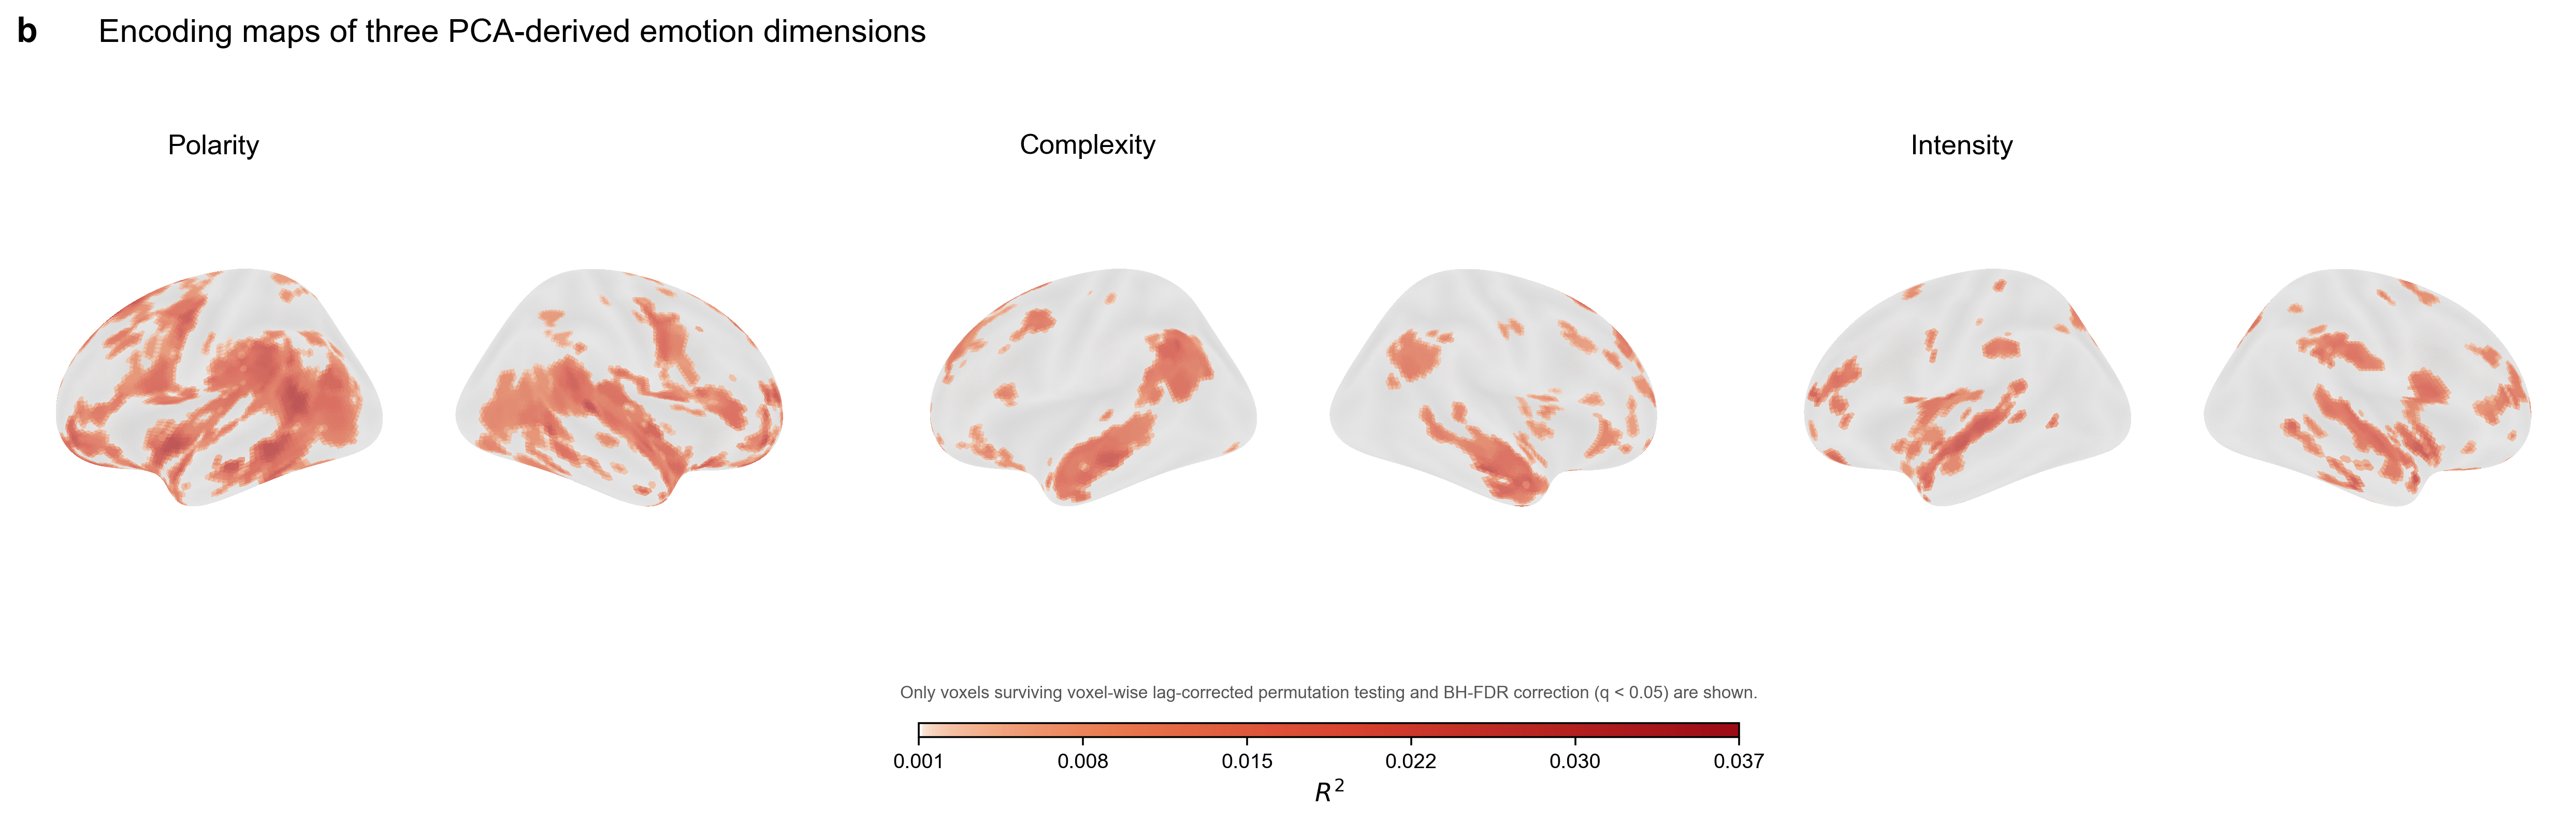

In [120]:
# ============================================================
# Render three PCA max-R2 surface maps
# ============================================================

def render_three_pca_surface_maps(
    output_png
):


    bg_left, bg_right = (
        build_gray_backgrounds(
            fsaverage
        )
    )


    cmap = make_red_colormap(
        COLOR_GAMMA
    )


    fig = plt.figure(
        figsize=(16.5,4.8),
        facecolor="white"
    )


    grid = fig.add_gridspec(
        1,
        3,
        left=0.04,
        right=0.97,
        top=0.82,
        bottom=0.16,
        wspace=0.10,
    )



    for i, component in enumerate(
        PCA_COMPONENTS
    ):


        cell = grid[
            i
        ].subgridspec(
            1,
            2,
            wspace=0.015
        )


        # modal_lag = (
        #     pca_manifest_by_component
        #     .loc[
        #         component,
        #         "modal_optimal_lag_seconds"
        #     ]
        # )



        for j, (hemi, mesh, bg) in enumerate(
            [
                (
                    "left",
                    fsaverage.infl_left,
                    bg_left
                ),

                (
                    "right",
                    fsaverage.infl_right,
                    bg_right
                ),
            ]
        ):


            ax = fig.add_subplot(
                cell[0,j],
                projection="3d"
            )


            tex = (
                pca_max_r2_textures
                [component]
                [hemi]
            )


            plotting.plot_surf_stat_map(
                mesh,
                # tex,
                np.nan_to_num(
                    tex,
                    nan=0
                ),

                hemi=hemi,

                view=SURFACE_VIEW,

                bg_map=bg,

                bg_on_data=True,

                cmap=cmap,

                symmetric_cbar=False,

                vmin=COLORBAR_MIN_R2,

                vmax=pca_shared_vmax,

                threshold=DISPLAY_MIN_R2,

                alpha=0.96,

                colorbar=False,

                figure=fig,

                axes=ax,
            )


            ax.set_axis_off()



            if hemi=="left":

                ax.set_title(
                    f"{component}\n",
                    # f"modal lag={modal_lag:+.0f}s",

                    fontsize=12,

                    pad=5
                )



    # --------------------------------------------------------
    # Colorbar
    # --------------------------------------------------------

    cax = fig.add_axes(
        [
            0.37,
            0.055,
            0.30,
            0.018
        ]
    )


    scalar = mpl.cm.ScalarMappable(
        norm=Normalize(
            COLORBAR_MIN_R2,
            pca_shared_vmax
        ),
        cmap=cmap
    )


    scalar.set_array([])


    cb = fig.colorbar(
        scalar,
        cax=cax,
        orientation="horizontal"
    )


    cb.set_label(
        r"$R^2$",
        fontsize=11
    )


    ticks = np.linspace(
        COLORBAR_MIN_R2,
        pca_shared_vmax,
        6
    )


    cb.set_ticks(
        ticks
    )


    cb.set_ticklabels(
        [
            f"{x:.3f}"
            for x in ticks
        ]
    )


    cb.ax.tick_params(
        labelsize=9
    )


    fig.text(
        0.52,
        0.11,
        "Only voxels surviving voxel-wise lag-corrected permutation testing and BH-FDR correction (q < 0.05) are shown.",
        ha="center",
        va="center",
        fontsize=7.5,
        color="#555555",
    )


    fig.text(
        0.04,
        0.93,
        "b",
        fontsize=15,
        fontweight="bold",
    )


    fig.text(
        0.07,
        0.93,
        "Encoding maps of three PCA-derived emotion dimensions",
        fontsize=14,
    )


    fig.savefig(
        output_png,
        dpi=320,
        bbox_inches="tight",
        facecolor="white"
    )


    plt.close(fig)



# Run
PCA_R2_FIG = (
    OUTPUT_DIR /
    "three_PCA_voxelwise_maxR2_surface_maps.png"
)


render_three_pca_surface_maps(
    PCA_R2_FIG
)


print(
    PCA_R2_FIG
)

display(
    NotebookImage(
        filename=str(PCA_R2_FIG)
    )
)

In [121]:
# ============================================================
# Prepare PCA voxel-specific optimal lag textures
# ============================================================

pca_optimal_lag_textures = {}


pca_manifest_by_component = (
    pca_manifest
    .set_index("component")
)


for component in PCA_COMPONENTS:

    row = (
        pca_manifest_by_component
        .loc[component]
    )


    # IMPORTANT:
    # use significant optimal lag map
    lag_img = nib.load(
        str(
            row[
                "nifti_significant_optimal_lag"
            ]
        )
    )

    
    lag_data = lag_img.get_fdata(
        dtype=np.float32
    )

    lag_data[
        ~np.isfinite(lag_data)
    ] = np.nan


    pca_optimal_lag_textures[component] = {}


    for hemi in (
        "left",
        "right"
    ):

        pial = getattr(
            fsaverage,
            f"pial_{hemi}"
        )


        pca_optimal_lag_textures[component][hemi] = (
            voxel_to_surface_keep_sign(
                lag_img,
                lag_data,
                cortical_mask,
                pial,
                hemi,
            )
        )

In [122]:
component="Polarity"

row = pca_manifest_by_component.loc[component]

lag_img = nib.load(
    row["nifti_significant_optimal_lag"]
)

lag_data = lag_img.get_fdata()

print(
    "NIfTI finite:",
    np.isfinite(lag_data).sum()
)

print(
    "NIfTI zero:",
    np.sum(lag_data==0)
)

print(
    "unique finite:",
    np.unique(
        lag_data[np.isfinite(lag_data)]
    )[:20]
)

NIfTI finite: 3486
NIfTI zero: 392
unique finite: [-12. -10.  -8.  -6.  -4.  -2.   0.   2.   4.   6.   8.  10.  12.]


In [123]:
for component in PCA_COMPONENTS:

    tex = pca_optimal_lag_textures[component]["left"]

    print(
        component,
        "min=", np.nanmin(tex),
        "max=", np.nanmax(tex),
        "NaN=", np.sum(~np.isfinite(tex)),
        "zero=", np.sum(tex == 0),
        "total=", len(tex)
    )

Polarity min= -12.0 max= 12.0 NaN= 6760 zero= 354 total= 10242
Complexity min= -12.0 max= 12.0 NaN= 8756 zero= 232 total= 10242
Intensity min= -12.0 max= 12.0 NaN= 9067 zero= 132 total= 10242


In [113]:
print(
    component,
    "min=", np.nanmin(tex),
    "max=", np.nanmax(tex),
    "NaN=", np.sum(~np.isfinite(tex)),
    "zero=", np.sum(tex == 0),
    "total=", len(tex)
)

Polarity min= -12.0 max= 12.0 NaN= 7860 zero= 2130 total= 10242


\\10.16.57.94\dataset1\xinke\Danmu\fmri_lag_selection_emotion_pca\fmri_lag_selection_emotion_pca\results\pca3\three_PCA_voxelwise_optimal_lag_surface_maps.png


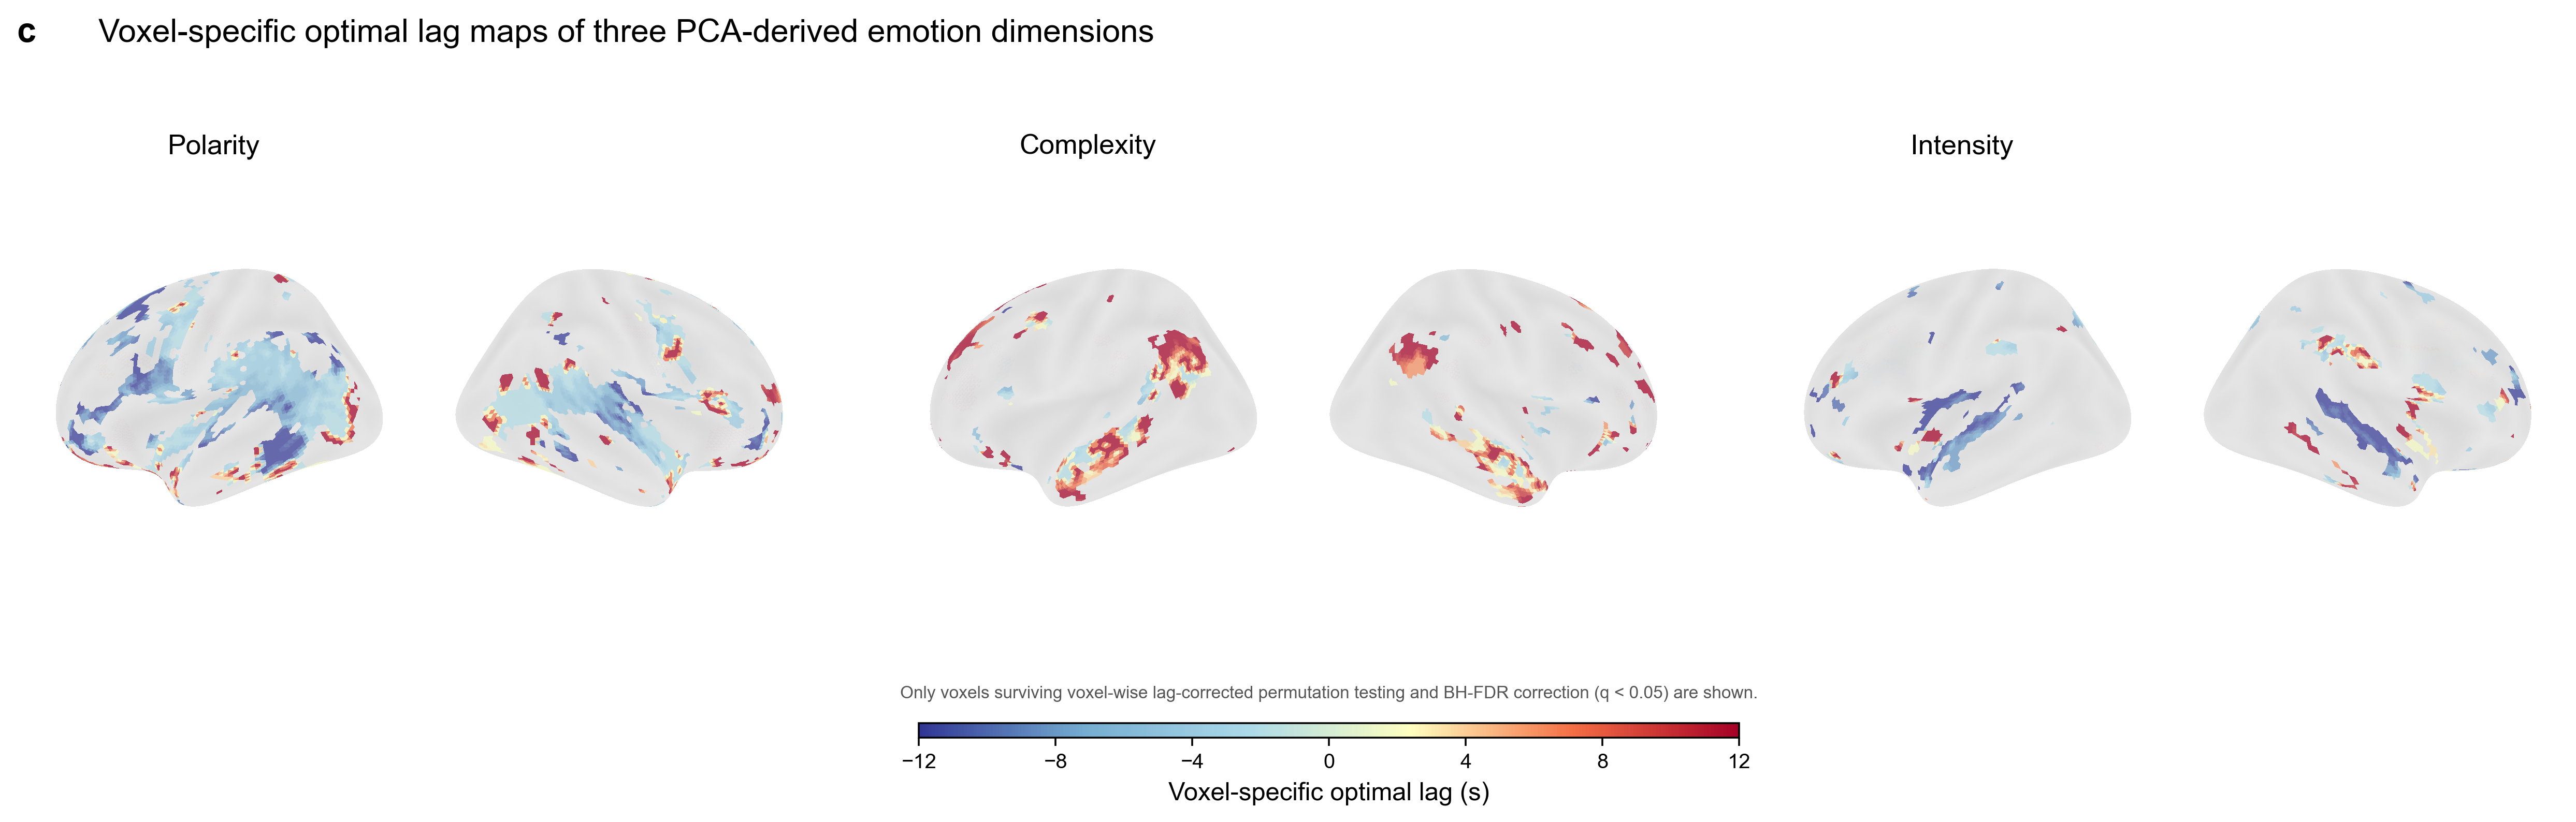

In [124]:
# ============================================================
# Render three PCA optimal lag surface maps
# ============================================================

def render_three_pca_optimal_lag_maps(
    output_png
):


    bg_left, bg_right = (
        build_gray_backgrounds(
            fsaverage
        )
    )


    cmap = lag_cmap


    fig = plt.figure(
        figsize=(16.5,4.8),
        facecolor="white"
    )


    grid = fig.add_gridspec(
        1,
        3,
        left=0.04,
        right=0.97,
        top=0.82,
        bottom=0.16,
        wspace=0.10,
    )



    for i, component in enumerate(
        PCA_COMPONENTS
    ):


        cell = grid[
            i
        ].subgridspec(
            1,
            2,
            wspace=0.015
        )


        # modal_lag = (
        #     pca_manifest_by_component
        #     .loc[
        #         component,
        #         "modal_optimal_lag_seconds"
        #     ]
        # )


        for j, (
            hemi,
            mesh,
            bg
        ) in enumerate(
            [
                (
                    "left",
                    fsaverage.infl_left,
                    bg_left
                ),

                (
                    "right",
                    fsaverage.infl_right,
                    bg_right
                )
            ]
        ):


            ax = fig.add_subplot(
                cell[0,j],
                projection="3d"
            )
            
            tex = (
                pca_optimal_lag_textures
                [component]
                [hemi]
                .copy()
            )


            # keep non-significant regions transparent
            tex[
                ~np.isfinite(tex)
            ] = np.nan
            
            tex = np.array(tex)
            tex[tex == 0] = tex[tex == 0] + 12


            # tex = (
            #     pca_optimal_lag_textures
            #     [component]
            #     [hemi]
            # )


            # # NaN stays transparent
            # tex = np.ma.masked_invalid(
            #     tex
            # )


            plotting.plot_surf_stat_map(
                mesh,
                tex,
                hemi=hemi,
                view=SURFACE_VIEW,
                bg_map=bg,
                bg_on_data=True,
                cmap=lag_cmap,
                symmetric_cbar=True,
                vmin=-12,
                vmax=12,
                threshold=None,
                colorbar=False,
                alpha=0.96,
                axes=ax,
                figure=fig,
            )
            


            ax.set_axis_off()



            if hemi=="left":

                ax.set_title(
                    f"{component}\n",
                    # f"modal lag={modal_lag:+.0f}s",

                    fontsize=12,

                    pad=5
                )



    # --------------------------------------------------------
    # Colorbar
    # --------------------------------------------------------

    cax = fig.add_axes(
        [
            0.37,
            0.055,
            0.30,
            0.018
        ]
    )


    sm = mpl.cm.ScalarMappable(
        norm=Normalize(
            -12,
            12
        ),
        cmap=lag_cmap
    )


    sm.set_array([])


    cb = fig.colorbar(
        sm,
        cax=cax,
        orientation="horizontal"
    )


    cb.set_label(
        "Voxel-specific optimal lag (s)",
        fontsize=11
    )


    cb.set_ticks(
        [-12,-8,-4,0,4,8,12]
    )


    cb.ax.tick_params(
        labelsize=9
    )



    fig.text(
        0.52,
        0.11,
        "Only voxels surviving voxel-wise lag-corrected permutation testing and BH-FDR correction (q < 0.05) are shown.",
        ha="center",
        va="center",
        fontsize=7.5,
        color="#555555",
    )


    fig.text(
        0.04,
        0.93,
        "c",
        fontsize=15,
        fontweight="bold",
    )


    fig.text(
        0.07,
        0.93,
        "Voxel-specific optimal lag maps of three PCA-derived emotion dimensions",
        fontsize=14,
    )


    fig.savefig(
        output_png,
        dpi=320,
        bbox_inches="tight",
        facecolor="white"
    )


    plt.close(fig)



PCA_LAG_FIG = (
    OUTPUT_DIR /
    "three_PCA_voxelwise_optimal_lag_surface_maps.png"
)


render_three_pca_optimal_lag_maps(
    PCA_LAG_FIG
)


print(
    PCA_LAG_FIG
)


display(
    NotebookImage(
        filename=str(PCA_LAG_FIG)
    )
)

In [125]:
import nibabel as nib
import numpy as np
import pandas as pd

from nilearn import datasets, image


# ============================================================
# Load Harvard-Oxford
# ============================================================

atlas = datasets.fetch_atlas_harvard_oxford(
    "cort-maxprob-thr25-2mm"
)


atlas_img = (
    atlas.maps
    if isinstance(atlas.maps, nib.Nifti1Image)
    else nib.load(atlas.maps)
)


atlas_labels = atlas.labels



# ============================================================
# ROI peak extraction
# ============================================================

def get_top_roi_peaks_pca(
    r2_path,
    atlas_img,
    atlas_labels,
    topk=5,
):


    r2_img = nib.load(
        r2_path
    )


    r2_data = r2_img.get_fdata(
        dtype=np.float32
    )


    # atlas align
    atlas_resampled = image.resample_to_img(
        atlas_img,
        r2_img,
        interpolation="nearest"
    )


    atlas_data = (
        atlas_resampled
        .get_fdata()
    )



    rows=[]


    for roi_id, roi_name in enumerate(
        atlas_labels
    ):


        # skip background

        if roi_id == 0:
            continue


        roi_mask = (
            atlas_data == roi_id
        )


        sig_mask = (
            roi_mask
            &
            np.isfinite(r2_data)
            &
            (r2_data>0)
        )


        if sig_mask.sum()==0:
            continue



        values = r2_data[
            sig_mask
        ]


        ijk = np.column_stack(
            np.where(sig_mask)
        )


        idx = np.argmax(
            values
        )


        peak_ijk = ijk[idx]


        peak_r2 = values[idx]


        peak_mni = nib.affines.apply_affine(
            r2_img.affine,
            peak_ijk
        )


        hemi = (
            "Left"
            if peak_mni[0]<0
            else "Right"
        )


        rows.append(
            {
                "ROI":
                    roi_name,

                "Hemisphere":
                    hemi,

                "Peak_R2":
                    float(peak_r2),

                "MNI_x":
                    float(peak_mni[0]),

                "MNI_y":
                    float(peak_mni[1]),

                "MNI_z":
                    float(peak_mni[2]),

                "n_sig_voxels":
                    int(sig_mask.sum()),
            }
        )



    df = pd.DataFrame(rows)


    df = (
        df
        .sort_values(
            "Peak_R2",
            ascending=False
        )
        .head(topk)
        .reset_index(drop=True)
    )


    df.insert(
        0,
        "Rank",
        np.arange(
            1,
            len(df)+1
        )
    )


    return df

In [126]:
all_pca_roi_rows=[]


for component in PCA_COMPONENTS:


    row = pca_manifest[
        pca_manifest["component"]
        ==
        component
    ].iloc[0]


    roi_df = get_top_roi_peaks_pca(
        row["nifti_significant_r2"],
        atlas_img,
        atlas_labels,
        topk=5
    )


    roi_df.insert(
        0,
        "Component",
        component
    )


    all_pca_roi_rows.append(
        roi_df
    )



pca_top_roi_df = pd.concat(
    all_pca_roi_rows,
    ignore_index=True
)


display(
    pca_top_roi_df
)



pca_top_roi_df.to_csv(
    FIG_DIR /
    "pca3_top5_ROI_peak_R2_HarvardOxford.csv",
    index=False,
    encoding="utf-8-sig"
)

,Component,Rank,ROI,Hemisphere,Peak_R2,MNI_x,MNI_y,MNI_z,n_sig_voxels
0,Polarity,1,Temporal Pole,Right,0.036780,37.5,10.5,-46.5,121
1,Polarity,2,Superior Frontal Gyrus,Left,0.031324,-16.5,34.5,52.5,107
2,Polarity,3,Frontal Orbital Cortex,Left,0.030918,-16.5,7.5,-16.5,35
3,Polarity,4,Frontal Pole,Right,0.030604,43.5,58.5,-7.5,301
4,Polarity,5,"Middle Temporal Gyrus, temporooccipital part",Left,0.030185,-49.5,-52.5,10.5,134
5,Complexity,1,Frontal Pole,Left,0.027471,-4.5,61.5,-13.5,92
6,Complexity,2,"Middle Temporal Gyrus, posterior division",Right,0.026842,67.5,-13.5,-13.5,114
7,Complexity,3,"Middle Temporal Gyrus, anterior division",Right,0.023925,52.5,1.5,-28.5,83
8,Complexity,4,Angular Gyrus,Left,0.023769,-55.5,-58.5,34.5,110
9,Complexity,5,Superior Frontal Gyrus,Right,0.021501,4.5,52.5,31.5,94


In [128]:
ROI_CSV = FIG_DIR / "six_emotion_top5_ROI_peak_R2_HarvardOxford.csv"

In [129]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nilearn import datasets, surface, plotting
from scipy.spatial import cKDTree
import matplotlib as mpl


roi_df = pd.read_csv(
    ROI_CSV
)


fsaverage = datasets.fetch_surf_fsaverage(
    "fsaverage5"
)


print(roi_df.head())

def mni_to_surface_vertex(
    mni_xyz,
    hemi,
    fsaverage,
):

    if hemi == "Left":

        mesh_path = fsaverage.pial_left

    else:

        mesh_path = fsaverage.pial_right


    mesh = surface.load_surf_mesh(
        mesh_path
    )

    vertices = np.asarray(
        mesh.coordinates,
        dtype=np.float32
    )


    tree = cKDTree(
        vertices
    )


    dist, idx = tree.query(
        np.asarray(mni_xyz),
        k=1
    )

    return idx, dist

     Emotion  Rank                       ROI Hemisphere   Peak_R2  MNI_x  \
0  Happiness     1             Planum Polare      Right  0.037457   49.5   
1  Happiness     2            Insular Cortex       Left  0.032227  -40.5   
2  Happiness     3             Temporal Pole      Right  0.030730   52.5   
3  Happiness     4  Central Opercular Cortex      Right  0.029249   52.5   
4  Happiness     5              Frontal Pole       Left  0.029197  -13.5   

   MNI_y  MNI_z  n_sig_voxels  
0    1.5   -4.5            65  
1   -4.5  -10.5            91  
2   10.5   -4.5            39  
3    7.5   -1.5            36  
4   46.5  -22.5           146  


In [130]:
EMOTION_COLORS = {
    "Happiness": "#d62728",
    "Surprise": "#1f77b4",
    "Sadness": "#9467bd",
    "Anger": "#2ca02c",
    "Disgust": "#ff7f0e",
    "Fear": "#8c564b",
}


roi_surface = {
    "left": [],
    "right": [],
}


for _, row in roi_df.iterrows():

    idx, dist = mni_to_surface_vertex(
        [
            row["MNI_x"],
            row["MNI_y"],
            row["MNI_z"],
        ],
        row["Hemisphere"],
        fsaverage,
    )


    roi_surface[
        row["Hemisphere"].lower()
    ].append(
        {
            "vertex": idx,
            "emotion": row["Emotion"],
            "rank": row["Rank"],
            "roi": row["ROI"],
            "r2": row["Peak_R2"],
            "dist": dist,
        }
    )

In [132]:
bg_left = surface.load_surf_data(
    fsaverage.sulc_left
)

bg_right = surface.load_surf_data(
    fsaverage.sulc_right
)


fig = plt.figure(
    figsize=(12,6),
    facecolor="white"
)


for i, hemi in enumerate(
    ["left","right"]
):

    ax = fig.add_subplot(
        1,
        2,
        i+1,
        projection="3d"
    )


    if hemi=="left":

        mesh = fsaverage.infl_left
        bg = bg_left

    else:

        mesh = fsaverage.infl_right
        bg = bg_right


    plotting.plot_surf_stat_map(
        mesh,
        np.zeros(
            len(
                surface.load_surf_mesh(mesh).coordinates
            )
        ),
        hemi=hemi,
        view="lateral",
        bg_map=bg,
        bg_on_data=True,
        cmap="Greys",
        colorbar=False,
        axes=ax,
        figure=fig,
    )


    ax.set_axis_off()


    # add points

    mesh_obj = surface.load_surf_mesh(
        mesh
    )

    vertices = np.asarray(
        mesh_obj.coordinates
    )


    for item in roi_surface[
        hemi
    ]:

        xyz = vertices[
            item["vertex"]
        ]


        ax.scatter(
            xyz[0],
            xyz[1],
            xyz[2],
            s=80,
            color=EMOTION_COLORS[item["emotion"]],
            edgecolor="white",
            linewidth=0.8,
            depthshade=False,
        )


        # ax.text(
        #     xyz[0],
        #     xyz[1],
        #     xyz[2],
        #     str(item["Rank"]),
        #     fontsize=8,
        #     color="black"
        # )


plt.tight_layout()

plt.savefig(
    FIG_DIR /
    "top5_ROI_peak_locations_surface.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

C:\Users\Windows\AppData\Local\Temp\ipykernel_19512\1673168697.py:111: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
